# Lattice CHT Optimisation — RBF-Parameterised Schwarz Primitive

Combines two codebases:
- **TOFLUX** — finite-element solver for 3-D conjugate heat transfer (Navier–Stokes–Brinkman + energy)
- **ImplicitRandomSchwarzPrimitive** — RBF-deformed Schwarz Primitive TPMS lattice

## Design parameterisation

Instead of a per-element density $\gamma_e$, the design is parameterised by
**RBF control-point displacements** $\mathbf{d}_j \in \mathbb{R}^3$:

1. Each element centroid is displaced: $\mathbf{x}'_e = \mathbf{x}_e + \sum_j A_{ej}\,\mathbf{d}_j$  
   where $A_{ej}$ is the pre-computed thin-plate-spline RBF influence matrix.
2. Schwarz Primitive SDF: $s_e = |\cos(k x'_e) + \cos(k y'_e) + \cos(k z'_e)| - s_0$
3. Smooth Heaviside: $\gamma_e = \tfrac{1}{2}(1 - \tanh(\beta\, s_e))$  
   ($\gamma \to 1$ = solid wall, $\gamma \to 0$ = fluid channel)
4. $\gamma$ enters RAMP interpolation for Brinkman permeability and thermal diffusivity.

This chain is fully JAX-differentiable: `jax.value_and_grad` propagates
through the CHT solve back to the RBF control-point displacements.

## Notebook flow

| Cell | Content |
|------|---------|
| 1–2  | Imports and domain parameters |
| 3    | Build TOFLUX meshes |
| 4    | RBF influence matrix (pre-computed, constant) |
| 5    | JAX lattice parameterisation $\mathbf{d} \to \gamma$ |
| 6    | Visualise initial Schwarz lattice |
| 7–8  | Materials, BCs, solvers |
| 9    | Differentiable objective function |
| 10   | **Single simulation run** |
| 11   | **Single optimisation step** (gradient descent) |
| 12   | Compare before/after |


## Cell 1 — Imports & Setup

In [1]:
import os, sys, functools, time
import numpy as np
import scipy.interpolate
import matplotlib.pyplot as plt

os.chdir('/workspace/LEAP71_version_KBE/TOFLUX_REPO')
sys.path.insert(0, os.getcwd())

import jax
import jax.numpy as jnp
from jax.typing import ArrayLike

import toflux.src.utils    as _utils
import toflux.src.material as _mat
import toflux.src.fe_thermal as _fea_thermal
import toflux.src.fe_fluid   as _fea_fluid
import toflux.src.solver     as _solv
import toflux.src.config     as _config

jax.config.update('jax_enable_x64', True)
plt.rcParams.update({'text.usetex': False})

_Ext = _utils.Extent
print('Imports OK')

Here i am
0.4.7
Imports OK


## Cell 2 — Domain, Lattice & RBF Parameters

All problem parameters are gathered here.

**Schwarz Primitive** — the SDF value is dimensionless:
$$
s_e = |\cos(k x'_e) + \cos(k y'_e) + \cos(k z'_e)| - s_0, \quad k = 2\pi / L_{\text{unit}}
$$
The inner sum ranges in $[-3, 3]$, so $s_0 \in (0, 3)$ controls the solid volume fraction
(larger $s_0$ → thicker walls → higher solid fraction).

**RBF field** — thin-plate-spline interpolation maps control-point displacements
to continuous 3-D displacement vectors at every element centroid.

In [2]:
# ── Domain ────────────────────────────────────────────────────────────────────
Lx, Ly, Lz   = 4.0, 1.0, 1.0   # m
nelx, nely, nelz = 40, 20, 20   # element counts (2 000 elements, fast)

# ── Schwarz Primitive lattice ─────────────────────────────────────────────────
# unit cell size in metres — choose so you get several cells in each direction
schwarz_unit      = 0.5          # m  → 8 cells along x, 2 along y/z
schwarz_s0        = 0.1          # dimensionless SDF threshold (controls solid fraction)
schwarz_k         = 2.0 * np.pi / schwarz_unit   # wavenumber (m^-1)
sdf_beta          = 15.0         # Heaviside sharpness (larger → crisper interface)

# ── RBF control-point grid ────────────────────────────────────────────────────
ctrl_spacing = 1.5               # m between control points

# ── Fluid physics ─────────────────────────────────────────────────────────────
reynolds_num = 3.0
rho_f = 1000.0;  mu_f = 6.6e-3
k_f   = 0.05;    cp_f  = 5000.0
k_s   = 0.5;     cp_s  = 5000.0

# ── Objective normalisation ───────────────────────────────────────────────────
fluid_obj_range   = (1e-9, 2e-8)
thermal_obj_range = (500.0, 8000.0)
obj_weight        = 0.5   # 0 = minimise dissipation only, 1 = maximise heat transfer only

# ── Temperatures ─────────────────────────────────────────────────────────────
T_inlet  = 0.0    # K (non-dimensional reference)
T_wall   = 10.0   # K (heated y-walls)

print(f'Schwarz: k = {schwarz_k:.3f} m⁻¹,  unit_size = {schwarz_unit} m')
print(f'Cells along x/y/z: {Lx/schwarz_unit:.0f} / {Ly/schwarz_unit:.0f} / {Lz/schwarz_unit:.0f}')

Schwarz: k = 12.566 m⁻¹,  unit_size = 0.5 m
Cells along x/y/z: 8 / 2 / 2


## Cell 3 — Build TOFLUX Meshes

In [3]:
cfg = {
    'domain': {
        'nel': [nelx, nely, nelz],
        'extents': {'x': [0.0, Lx], 'y': [0.0, Ly], 'z': [0.0, Lz]},
    },
    'geometry': {'type': 'rectangular'},
    'physics': {
        'reynolds_number': reynolds_num,
        'char_length_axis': 'y',
        'fluid': {
            'mass_density': rho_f, 'dynamic_viscosity': mu_f,
            'thermal_conductivity': k_f, 'specific_heat': cp_f,
        },
        'solid': {
            'mass_density': rho_f,
            'thermal_conductivity': k_s, 'specific_heat': cp_s,
        },
    },
    'optimization': {
        'gauss_order': 2, 'desired_mat_frac': 0.5,
        'obj_weight': obj_weight, 'max_iter': 100, 'move_limit': 0.15,
    },
    'fluid_bcs': [
        {'name': 'Wall', 'type': 'wall',
         'faces': [{'axis': 'y', 'value': 0.0}, {'axis': 'y', 'value': Ly},
                   {'axis': 'z', 'value': 0.0}, {'axis': 'z', 'value': Lz}]},
        {'name': 'Inlet',  'type': 'inlet_parabolic', 'face': {'axis': 'x', 'value': 0.0}},
        {'name': 'Outlet', 'type': 'outlet',           'face': {'axis': 'x', 'value': Lx}},
    ],
    'thermal_bcs': [
        {'name': 'Inlet BC',     'type': 'fixed_temperature', 'temperature': T_inlet,
         'face': {'axis': 'x', 'value': 0.0}},
        {'name': 'Heated Walls', 'type': 'fixed_temperature', 'temperature': T_wall,
         'faces': [{'axis': 'y', 'value': 0.0}, {'axis': 'y', 'value': Ly}]},
    ],
}

fluid_mesh, thermal_mesh = _config.build_mesh_pair(cfg)

print(f'Fluid mesh   : {fluid_mesh.num_elems:,} elements, {fluid_mesh.num_dofs:,} DOFs')
print(f'Thermal mesh : {thermal_mesh.num_elems:,} elements, {thermal_mesh.num_dofs:,} DOFs')
print(f'Element size : {float(fluid_mesh.elem_size[0]):.3f} × '
      f'{float(fluid_mesh.elem_size[1]):.3f} × {float(fluid_mesh.elem_size[2]):.3f} m')

Fluid mesh   : 16,000 elements, 72,324 DOFs
Thermal mesh : 16,000 elements, 18,081 DOFs
Element size : 0.100 × 0.050 × 0.050 m


## Cell 4 — RBF Influence Matrix

We pre-compute the **thin-plate-spline RBF influence matrix** $A \in \mathbb{R}^{N_e \times N_c}$
where $N_e$ = number of elements and $N_c$ = number of control points.

This matrix encodes the linear map from control-point displacements to
element-centroid displacements:
$$
\Delta\mathbf{X}_e = A\,\mathbf{D}_c
$$
Because $A$ is constant throughout optimisation, we compute it once in NumPy
in batches and store it as a compact JAX array. Using float32 here keeps the
mesh resolution unchanged while lowering peak memory during the build and solve.
Autodiff through `A @ ctrl_disp` is automatic.

In [4]:
# ── Control-point grid (covers domain + margin) ────────────────────────────────
margin = ctrl_spacing * 0.5
ctrl_axes = [
    np.arange(-margin, L + margin + 1e-8, ctrl_spacing)
    for L in (Lx, Ly, Lz)
]
GX, GY, GZ = np.meshgrid(*ctrl_axes, indexing='ij')
ctrl_pts = np.column_stack([GX.ravel(), GY.ravel(), GZ.ravel()]).astype(np.float32)
n_ctrl   = len(ctrl_pts)
print(f'Control-point grid : {GX.shape}  →  {n_ctrl} points')

# ── Element centroids from the thermal mesh ────────────────────────────────────
elem_centroids = np.array(thermal_mesh.elem_centers, dtype=np.float32)   # (n_elems, 3)
n_elems = thermal_mesh.num_elems

# ── Build influence matrix in batches ──────────────────────────────────────────
# A_rbf[i, j] = interpolated displacement at element i when control point j = 1
print(f'Computing RBF influence matrix ({n_elems} × {n_ctrl}) …')
t0 = time.time()
basis = scipy.interpolate.RBFInterpolator(
    ctrl_pts, np.eye(n_ctrl, dtype=np.float32), kernel='thin_plate_spline', degree=1
)
A_rbf = np.empty((n_elems, n_ctrl), dtype=np.float32)
rbf_chunk = 512
for start in range(0, n_elems, rbf_chunk):
    stop = min(start + rbf_chunk, n_elems)
    A_rbf[start:stop] = basis(elem_centroids[start:stop]).astype(np.float32, copy=False)

A_rbf_jax = jnp.asarray(A_rbf)          # compact JAX array for autodiff
print(f'Done in {time.time()-t0:.1f}s   shape: {A_rbf.shape}')

Control-point grid : (4, 2, 2)  →  16 points
Computing RBF influence matrix (16000 × 16) …
Done in 0.0s   shape: (16000, 16)


## Cell 5 — Lattice Parameterisation in JAX

The function `lattice_mat_frac(ctrl_disp_flat)` maps the flattened
design variables $\mathbf{d} \in \mathbb{R}^{3 N_c}$ to element material
fractions $\gamma \in [0,1]^{N_e}$.

Because every operation is a JAX primitive, `jax.grad` propagates gradients
through the entire chain automatically.

In [5]:
# Element centroids as a JAX constant
_centroids_jax = jnp.asarray(elem_centroids)   # (n_elems, 3)


def lattice_mat_frac(ctrl_disp_flat: jnp.ndarray) -> jnp.ndarray:
    """RBF ctrl_disp → Schwarz SDF → smooth γ.

    Args:
        ctrl_disp_flat: (n_ctrl * 3,)  flattened control-point displacements (m)

    Returns:
        mat_frac: (n_elems,) in [0, 1]   0 = fluid channel, 1 = solid wall
    """
    ctrl_disp = ctrl_disp_flat.reshape(n_ctrl, 3)      # (n_ctrl, 3)
    elem_disp = A_rbf_jax @ ctrl_disp                  # (n_elems, 3)
    pts = _centroids_jax + elem_disp                   # displaced centroids

    # Schwarz Primitive SDF (dimensionless)
    kappa = jnp.asarray(schwarz_k, dtype=pts.dtype)
    sdf0 = jnp.asarray(schwarz_s0, dtype=pts.dtype)
    beta = jnp.asarray(sdf_beta, dtype=pts.dtype)
    inner = (jnp.cos(kappa * pts[:, 0])
           + jnp.cos(kappa * pts[:, 1])
           + jnp.cos(kappa * pts[:, 2]))
    sdf = jnp.abs(inner) - sdf0

    # Smooth Heaviside: γ→1 inside wall (sdf<0), γ→0 in channel (sdf>0)
    return 0.5 * (1.0 - jnp.tanh(beta * sdf))


# ── Check initial design ───────────────────────────────────────────────────────
ctrl_disp_init = jnp.zeros(n_ctrl * 3, dtype=jnp.float32)
mat_frac_init  = np.array(lattice_mat_frac(ctrl_disp_init), dtype=np.float32)
print(f'Initial γ — mean: {mat_frac_init.mean():.3f}  '
      f'min: {mat_frac_init.min():.3f}  max: {mat_frac_init.max():.3f}')
print(f'Solid fraction (γ>0.5): {(mat_frac_init > 0.5).mean():.1%}')

Initial γ — mean: 0.048  min: 0.000  max: 0.822
Solid fraction (γ>0.5): 4.8%


## Cell 6 — Visualise Initial Schwarz Lattice

Three orthogonal cross-sections of the initial $\gamma$ field (undistorted Schwarz Primitive).

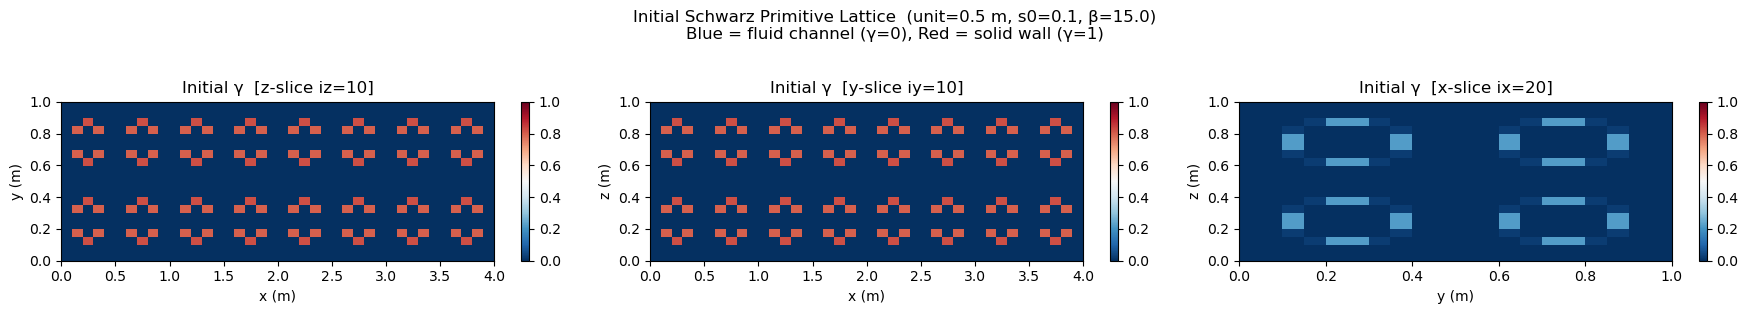

In [6]:
def plot_slice(mesh, field, title='', axis='z', idx=None, ax=None, figsize=(8, 3), **kw):
    """2-D cross-section of a 3-D element field on a GridMesh."""
    f3 = np.asarray(field).reshape(mesh.nelx, mesh.nely, mesh.nelz)
    bb = mesh.bounding_box
    if axis == 'z':
        iz  = idx if idx is not None else mesh.nelz // 2
        fsl = f3[:, :, iz].T
        ext = [float(bb.x.min), float(bb.x.max), float(bb.y.min), float(bb.y.max)]
        xl, yl, info = 'x (m)', 'y (m)', f'z-slice iz={iz}'
    elif axis == 'y':
        iy  = idx if idx is not None else mesh.nely // 2
        fsl = f3[:, iy, :].T
        ext = [float(bb.x.min), float(bb.x.max), float(bb.z.min), float(bb.z.max)]
        xl, yl, info = 'x (m)', 'z (m)', f'y-slice iy={iy}'
    else:
        ix  = idx if idx is not None else mesh.nelx // 2
        fsl = f3[ix, :, :].T
        ext = [float(bb.y.min), float(bb.y.max), float(bb.z.min), float(bb.z.max)]
        xl, yl, info = 'y (m)', 'z (m)', f'x-slice ix={ix}'
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(fsl, origin='lower', extent=ext, aspect='auto', **kw)
    plt.colorbar(im, ax=ax)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(f'{title}  [{info}]' if title else info)
    return ax


fig, axes = plt.subplots(1, 3, figsize=(18, 3))
kw = dict(cmap='RdBu_r', vmin=0, vmax=1)
plot_slice(thermal_mesh, mat_frac_init, 'Initial γ',       axis='z', ax=axes[0], **kw)
plot_slice(thermal_mesh, mat_frac_init, 'Initial γ',       axis='y', ax=axes[1], **kw)
plot_slice(thermal_mesh, mat_frac_init, 'Initial γ',       axis='x', ax=axes[2], **kw)
plt.suptitle(
    f'Initial Schwarz Primitive Lattice  '
    f'(unit={schwarz_unit} m, s0={schwarz_s0}, β={sdf_beta})\n'
    f'Blue = fluid channel (γ=0), Red = solid wall (γ=1)',
    y=1.03
)
plt.tight_layout()
plt.show()

## Cell 7 — Materials, Physics & Boundary Conditions

In [7]:
# ── Material properties ────────────────────────────────────────────────────────
fluid_mat_prop, solid_mat_prop = _config.build_materials(cfg)

char_length   = _config.get_char_length(cfg)               # Ly = 1.0 m
char_velocity = reynolds_num * fluid_mat_prop.kinematic_viscosity / char_length

# Brinkman inverse-permeability bounds (penalise solid regions in fluid solve)
min_inv_perm  = _mat.brinkman_bound(fluid_mat_prop.dynamic_viscosity, 100  * fluid_mesh.bounding_box.lx)
max_inv_perm  = _mat.brinkman_bound(fluid_mat_prop.dynamic_viscosity, 1e-2 * fluid_mesh.bounding_box.lx)
init_inv_perm = _mat.brinkman_bound(fluid_mat_prop.dynamic_viscosity, 1e-1 * fluid_mesh.bounding_box.lx)

inv_perm_ext    = _Ext(min=min_inv_perm,           max=max_inv_perm)
diffusivity_ext = _Ext(min=fluid_mat_prop.diffusivity, max=solid_mat_prop.diffusivity)
fluid_obj_ext   = _Ext(min=fluid_obj_range[0],     max=fluid_obj_range[1])
thermal_obj_ext = _Ext(min=thermal_obj_range[0],   max=thermal_obj_range[1])

init_ramp_penalty = _mat.calculate_initial_ramp_penalty(inv_perm_ext, init_inv_perm, 0.5)

print(f'U_c = {char_velocity:.4e} m/s,  L = {char_length:.3f} m,  Re = {reynolds_num}')

# ── Boundary conditions ────────────────────────────────────────────────────────
face_tol   = float(min(fluid_mesh.elem_size)) * 0.5
temp_ext   = _config.build_temp_extent(cfg)
fluid_bc   = _config.build_fluid_bcs(cfg, fluid_mesh, char_velocity, face_tol)
thermal_bc = _config.build_thermal_bcs(cfg, thermal_mesh, temp_ext, face_tol)
inlet_elems, outlet_elems = _config.build_inlet_outlet_masks(cfg, thermal_mesh)

print(f'Fixed fluid DOFs   : {len(fluid_bc["fixed_dofs"])}')
print(f'Fixed thermal DOFs : {len(thermal_bc["fixed_dofs"])}')
print(f'Inlet elements     : {int(inlet_elems.sum())}')
print(f'Outlet elements    : {int(outlet_elems.sum())}')

U_c = 1.9800e-05 m/s,  L = 1.000 m,  Re = 3.0
Fixed fluid DOFs   : 12486
Fixed thermal DOFs : 2163
Inlet elements     : 400
Outlet elements    : 400


## Cell 8 — Solver Setup

In [8]:
import pypardiso   # Pardiso sparse solver (fast on CPU)

solver_settings = {
    # Use an algebraic-multigrid-preconditioned iterative solver to reduce memory
    'linear':    {'solver': _solv.LinearSolvers.AMG_CG, 'rtol': 1e-6},
    # Reduce nonlinear memory by keeping moderate iteration caps and tolerances
    'nonlinear': {'max_iter': 12, 'threshold': 1e-8},
}

flow_solver = _fea_fluid.FluidSolver(
    fluid_mesh, fluid_bc, fluid_mat_prop, solver_settings=solver_settings
)
thermal_solver = _fea_thermal.FEA(
    mesh=thermal_mesh, material=solid_mat_prop,
    bc=thermal_bc, solver_settings=solver_settings,
)
print('Solvers ready.')

Solvers ready.


## Cell 9 — Objective Function

The full differentiable forward pass:
$$
\mathbf{d} \xrightarrow{\text{lattice\_mat\_frac}} \gamma
  \xrightarrow{\text{RAMP}} \alpha, \kappa_{\text{eff}}
  \xrightarrow{\text{N–S–B}} \mathbf{u}
  \xrightarrow{\text{energy}} T
  \xrightarrow{} J
$$

Objective (same formulation as the standard CHT topology optimisation):
$$
J = (1-W)\,\hat{J}_f - W\,\hat{J}_{th}
$$
where $\hat{J}_f$ is normalised viscous dissipation and $\hat{J}_{th}$ is
normalised recovered thermal power.

In [9]:
@functools.partial(jax.jit, static_argnames=('flow_solver', 'thermal_solver'))
def forward_and_grad(
    ctrl_disp_flat: jnp.ndarray,
    flow_solver:    _fea_fluid.FluidSolver,
    thermal_solver: _fea_thermal.FEA,
    fluid_ramp:     float,
    thermal_ramp:   float,
    press_vel_guess: jnp.ndarray,
    temp_guess:      jnp.ndarray,
):
    """JIT-compiled forward pass + reverse-mode gradient.

    Args:
        ctrl_disp_flat: (n_ctrl*3,) RBF control-point displacements — the design variable.
        flow_solver / thermal_solver: static FEA objects.
        fluid_ramp / thermal_ramp: RAMP penalty parameters.
        press_vel_guess / temp_guess: warm-start vectors from the previous iteration.

    Returns:
        obj        : scalar objective
        grad       : gradient w.r.t. ctrl_disp_flat, same shape
        elem_pv    : element-level pressure/velocity dofs   (for post-processing)
        temp_elem  : element temperatures (K)
        pv_solved  : global pressure/velocity vector       (warm-start next iter)
        t_solved   : global temperature vector              (warm-start next iter)
        therm_pwr  : dimensional recovered thermal power (W)
        norm_therm : normalised thermal objective component
        norm_diss  : normalised dissipation objective component
    """
    dof = fluid_mesh.nodes.dof_per_node  # 4 for 3-D: (p, u, v, w)

    def _loss(ctrl_disp_flat):
        # ── 1. Lattice → material fraction ───────────────────────────────────
        mat_frac = lattice_mat_frac(ctrl_disp_flat)   # (n_elems,)

        # ── 2. Fluid solve (Navier–Stokes–Brinkman) ──────────────────────────
        brinkman = _mat.compute_ramp_interpolation(
            prop=mat_frac, ramp_penalty=fluid_ramp,
            prop_ext=inv_perm_ext, mode='convex',
        )
        press_vel = _solv.modified_newton_raphson_solve(
            flow_solver, press_vel_guess, brinkman
        )

        # ── 3. Extract 3-D element velocities (p, u, v, w per node) ─────────
        elem_pv  = press_vel[fluid_mesh.elem_dof_mat]          # (elems, 32)
        elem_u   = elem_pv[:, 1::dof]                          # (elems, 8)
        elem_v   = elem_pv[:, 2::dof]
        elem_w   = elem_pv[:, 3::dof]
        n_vel    = fluid_mesh.num_dim * fluid_mesh.elem_template.num_nodes
        elem_vel = jnp.zeros((fluid_mesh.num_elems, n_vel))
        elem_vel = elem_vel.at[:, 0::fluid_mesh.num_dim].set(elem_u)
        elem_vel = elem_vel.at[:, 1::fluid_mesh.num_dim].set(elem_v)
        elem_vel = elem_vel.at[:, 2::fluid_mesh.num_dim].set(elem_w)
        conv_vel = elem_vel / char_velocity

        # ── 4. Thermal solve (advection-diffusion energy equation) ───────────
        eff_diff = _mat.compute_ramp_interpolation(
            prop=mat_frac, ramp_penalty=thermal_ramp,
            prop_ext=diffusivity_ext, mode='concave',
        )
        peclet   = char_length * char_velocity / eff_diff
        temp_nd  = _solv.modified_newton_raphson_solve(
            thermal_solver, temp_guess, conv_vel, peclet
        )
        temp_elem = (
            temp_nd[thermal_mesh.elem_dof_mat].mean(axis=1)
            * temp_ext.range + temp_ext.min
        )

        # ── 5. Compute objectives ────────────────────────────────────────────
        therm_pwr  = thermal_solver.thermal_power(
            temp_elem, elem_u, inlet_elems, outlet_elems
        )
        norm_therm = thermal_obj_ext.normalize_array(therm_pwr)

        elem_diss  = jax.vmap(flow_solver.compute_elem_dissipated_power)(
            brinkman, elem_pv, fluid_mesh.elem_node_coords
        )
        norm_diss  = fluid_obj_ext.normalize_array(jnp.sum(elem_diss))

        obj = (1.0 - obj_weight) * norm_diss - obj_weight * norm_therm

        return obj, (elem_pv, temp_elem, press_vel, temp_nd, therm_pwr, norm_therm, norm_diss)

    (val, aux), grad = jax.value_and_grad(_loss, has_aux=True)(ctrl_disp_flat)
    elem_pv, temp_elem, pv, t_nd, therm_pwr, nth, ndiss = aux
    return val, grad, elem_pv, temp_elem, pv, t_nd, therm_pwr, nth, ndiss


print('forward_and_grad() defined (will be JIT-compiled on first call).')

forward_and_grad() defined (will be JIT-compiled on first call).


## Cell 10 — Single Simulation Run

Run the coupled fluid–thermal solve with the **initial undistorted Schwarz lattice**
and compute the gradient of $J$ with respect to the RBF control-point displacements.

In [10]:
# ── Warm-start: apply Dirichlet BCs to zero vectors ───────────────────────────
pv_guess = jnp.zeros(flow_solver.mesh.num_dofs)
pv_guess = pv_guess.at[flow_solver.bc['fixed_dofs']].set(
    jnp.asarray(flow_solver.bc['dirichlet_values'], dtype=jnp.float64)
)

t_guess = jnp.zeros(thermal_solver.mesh.num_dofs)
t_guess = t_guess.at[thermal_solver.bc['fixed_dofs']].set(
    jnp.asarray(thermal_solver.bc['dirichlet_values'], dtype=jnp.float64)
)

# ── RAMP continuation parameters ──────────────────────────────────────────────
# Use moderate penalties to get well-defined solid/fluid regions
fluid_ramp   = init_ramp_penalty / 2.0
thermal_ramp = 0.05

print('Running initial simulation (first call triggers JIT compilation) …')
t0 = time.time()

ctrl_dv = ctrl_disp_init   # (n_ctrl*3,) all zeros

(obj0, grad0, elem_pv0, temp_elem0,
 pv0, t_nd0, therm0, nth0, ndiss0) = forward_and_grad(
    ctrl_dv, flow_solver, thermal_solver,
    fluid_ramp, thermal_ramp, pv_guess, t_guess
)

print(f'Done in {time.time()-t0:.1f} s')
print(f'  Objective J        : {float(obj0):.4e}')
print(f'  Thermal power Q_th : {float(therm0):.2f} W  (norm: {float(nth0):.4f})')
print(f'  Dissipation (norm) : {float(ndiss0):.4f}')
print(f'  |∇J|               : {float(jnp.linalg.norm(grad0)):.4e}')
print(f'  max |∂J/∂d_i|      : {float(jnp.max(jnp.abs(grad0))):.4e}')

Running initial simulation (first call triggers JIT compilation) …


2026-05-01 14:25:30.397728: E external/xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %gather.218 = s32[2,1,16384000]{2,1,0} gather(%constant.2416, %constant.1021), offset_dims={1,2}, collapsed_slice_dims={}, start_index_map={0}, index_vector_dim=1, slice_sizes={1,16384000}, metadata={op_name="jit(forward_and_grad)/jit(main)/jvp(while)/body/gather" source_file="/workspace/LEAP71_version_KBE/TOFLUX_REPO/toflux/src/fe_fluid.py" source_line=371}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-05-01 14:25:30.619959: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 1

: 

## Cell 11 — Visualise Initial Simulation Results

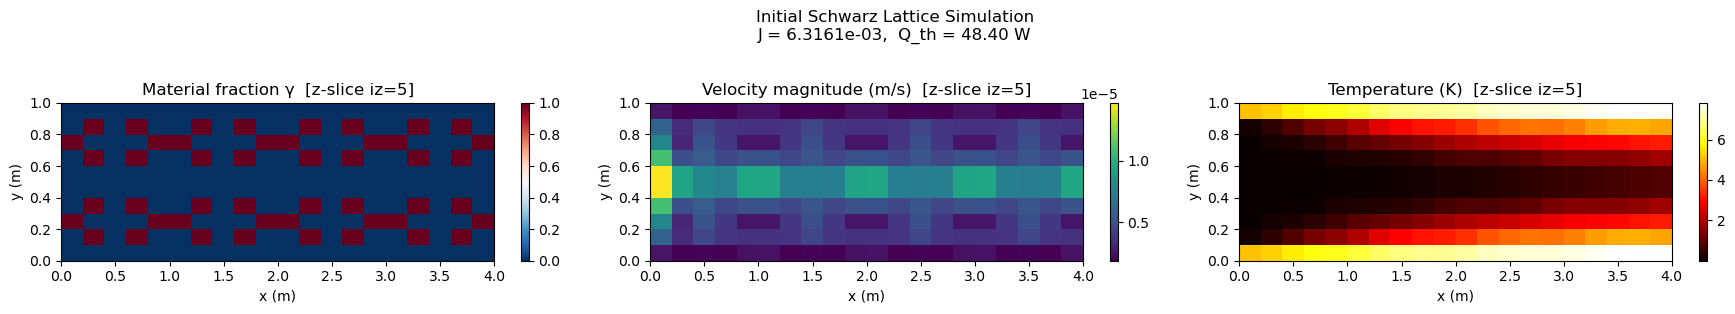

In [11]:
dof = flow_solver.mesh.nodes.dof_per_node
u_e0 = np.mean(np.array(elem_pv0[:, 1::dof]), axis=1)
v_e0 = np.mean(np.array(elem_pv0[:, 2::dof]), axis=1)
w_e0 = np.mean(np.array(elem_pv0[:, 3::dof]), axis=1)
vel_mag0 = np.sqrt(u_e0**2 + v_e0**2 + w_e0**2)

fig, axes = plt.subplots(1, 3, figsize=(18, 3))
plot_slice(thermal_mesh, mat_frac_init, 'Material fraction γ',   axis='z', ax=axes[0], cmap='RdBu_r', vmin=0, vmax=1)
plot_slice(fluid_mesh,   vel_mag0,      'Velocity magnitude (m/s)', axis='z', ax=axes[1], cmap='viridis')
plot_slice(thermal_mesh, np.array(temp_elem0), 'Temperature (K)', axis='z', ax=axes[2], cmap='hot')
plt.suptitle(
    f'Initial Schwarz Lattice Simulation\n'
    f'J = {float(obj0):.4e},  Q_th = {float(therm0):.2f} W',
    y=1.03
)
plt.tight_layout()
plt.show()

## Cell 12 — Single Optimisation Step

We minimise $J$ with a single gradient-descent step:
$$
\mathbf{d}^{(1)} = \mathbf{d}^{(0)} - \alpha\,\nabla_\mathbf{d} J
$$

The step size $\alpha$ is chosen by a simple **backtracking line search**
that halves $\alpha$ until the objective decreases (Armijo condition).

The gradient is already computed by `forward_and_grad` via JAX reverse-mode
autodiff through the full CHT solve.

In [12]:
# ── Gradient direction (steepest descent) ─────────────────────────────────────
descent = -grad0   # direction that decreases J

# ── Simple backtracking line search ───────────────────────────────────────────
alpha     = 1.0          # initial step size
alpha_min = 1e-4         # give up if step becomes too small
c_armijo  = 1e-4         # Armijo sufficient decrease constant
grad_dot  = float(jnp.dot(grad0, descent))   # = -|grad|^2  (always negative)

print(f'Starting backtracking line search  (|grad| = {float(jnp.linalg.norm(grad0)):.3e}) …')
step_taken = False

# Warm-start for subsequent solves
pv_warm = jax.lax.stop_gradient(pv0)
pv_warm = pv_warm.at[flow_solver.bc['fixed_dofs']].set(flow_solver.bc['dirichlet_values'])
t_warm  = jax.lax.stop_gradient(t_nd0)
t_warm  = t_warm.at[thermal_solver.bc['fixed_dofs']].set(thermal_solver.bc['dirichlet_values'])

for trial in range(8):
    ctrl_dv_new = ctrl_dv + alpha * descent
    (obj_try, grad_new, elem_pv1, temp_elem1,
     pv1, t_nd1, therm1, nth1, ndiss1) = forward_and_grad(
        ctrl_dv_new, flow_solver, thermal_solver,
        fluid_ramp, thermal_ramp, pv_warm, t_warm
    )
    obj_try_f = float(obj_try)
    print(f'  α = {alpha:.2e}  →  J = {obj_try_f:.4e}', end='')
    if obj_try_f <= float(obj0) + c_armijo * alpha * grad_dot:
        print('  ✓ accepted')
        step_taken = True
        break
    print('  ✗ reducing α')
    alpha *= 0.5
    if alpha < alpha_min:
        print('  Line search failed (step too small); keeping last trial.')
        step_taken = True
        break

print()
print(f'Step result:')
print(f'  J            : {float(obj0):.4e}  →  {float(obj_try):.4e}  (Δ = {float(obj_try)-float(obj0):.4e})')
print(f'  Thermal power: {float(therm0):.2f} W  →  {float(therm1):.2f} W')
print(f'  Step size α  : {alpha:.2e}')
print(f'  |Δd|_max     : {float(jnp.max(jnp.abs(ctrl_dv_new - ctrl_dv))):.4e} m')

Starting backtracking line search  (|grad| = 5.069e-02) …
NR converged in 4 iters, res_norm/res_norm_0: 1.6193847646333495e-13
NR converged in 2 iters, res_norm/res_norm_0: 7.381663452003395e-15
  α = 1.00e+00  →  J = 4.5678e-03  ✓ accepted

Step result:
  J            : 6.3161e-03  →  4.5678e-03  (Δ = -1.7483e-03)
  Thermal power: 48.40 W  →  74.45 W
  Step size α  : 1.00e+00
  |Δd|_max     : 4.6268e-02 m


## Cell 13 — Compare Before & After

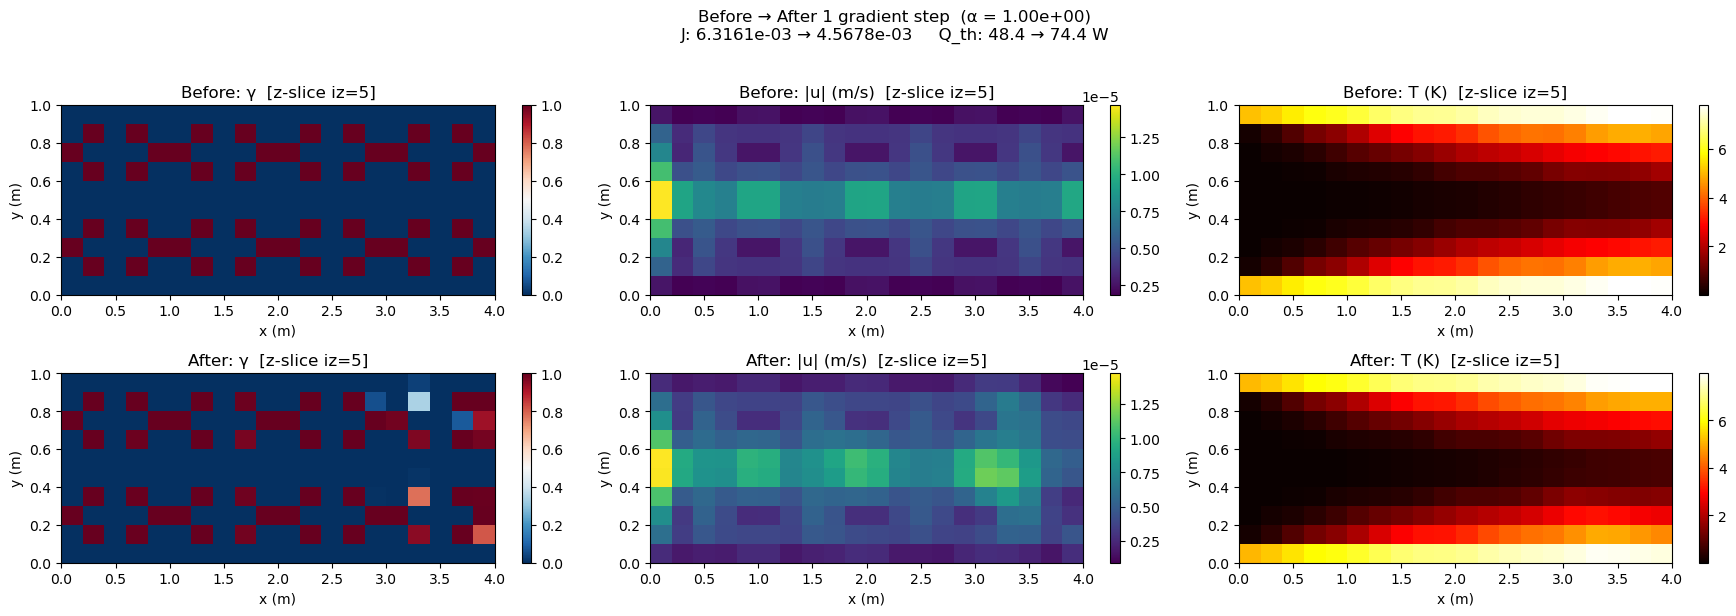

In [13]:
mat_frac_new = np.array(lattice_mat_frac(ctrl_dv_new))

u_e1 = np.mean(np.array(elem_pv1[:, 1::dof]), axis=1)
v_e1 = np.mean(np.array(elem_pv1[:, 2::dof]), axis=1)
w_e1 = np.mean(np.array(elem_pv1[:, 3::dof]), axis=1)
vel_mag1 = np.sqrt(u_e1**2 + v_e1**2 + w_e1**2)

fig, axes = plt.subplots(2, 3, figsize=(18, 6))

# ── Before ─────────────────────────────────────────────────────────────────────
plot_slice(thermal_mesh, mat_frac_init,          'Before: γ',           axis='z', ax=axes[0, 0], cmap='RdBu_r', vmin=0, vmax=1)
plot_slice(fluid_mesh,   vel_mag0,               'Before: |u| (m/s)',   axis='z', ax=axes[0, 1], cmap='viridis')
plot_slice(thermal_mesh, np.array(temp_elem0),   'Before: T (K)',       axis='z', ax=axes[0, 2], cmap='hot')

# ── After ──────────────────────────────────────────────────────────────────────
plot_slice(thermal_mesh, mat_frac_new,           'After: γ',            axis='z', ax=axes[1, 0], cmap='RdBu_r', vmin=0, vmax=1)
plot_slice(fluid_mesh,   vel_mag1,               'After: |u| (m/s)',    axis='z', ax=axes[1, 1], cmap='viridis')
plot_slice(thermal_mesh, np.array(temp_elem1),   'After: T (K)',        axis='z', ax=axes[1, 2], cmap='hot')

plt.suptitle(
    f'Before → After 1 gradient step  (α = {alpha:.2e})\n'
    f'J: {float(obj0):.4e} → {float(obj_try):.4e}     '
    f'Q_th: {float(therm0):.1f} → {float(therm1):.1f} W',
    y=1.02, fontsize=12
)
plt.tight_layout()
plt.show()

## Cell 14 — RBF Control-Point Visualisation

Show how the control-point displacements changed and where the gradient is largest.

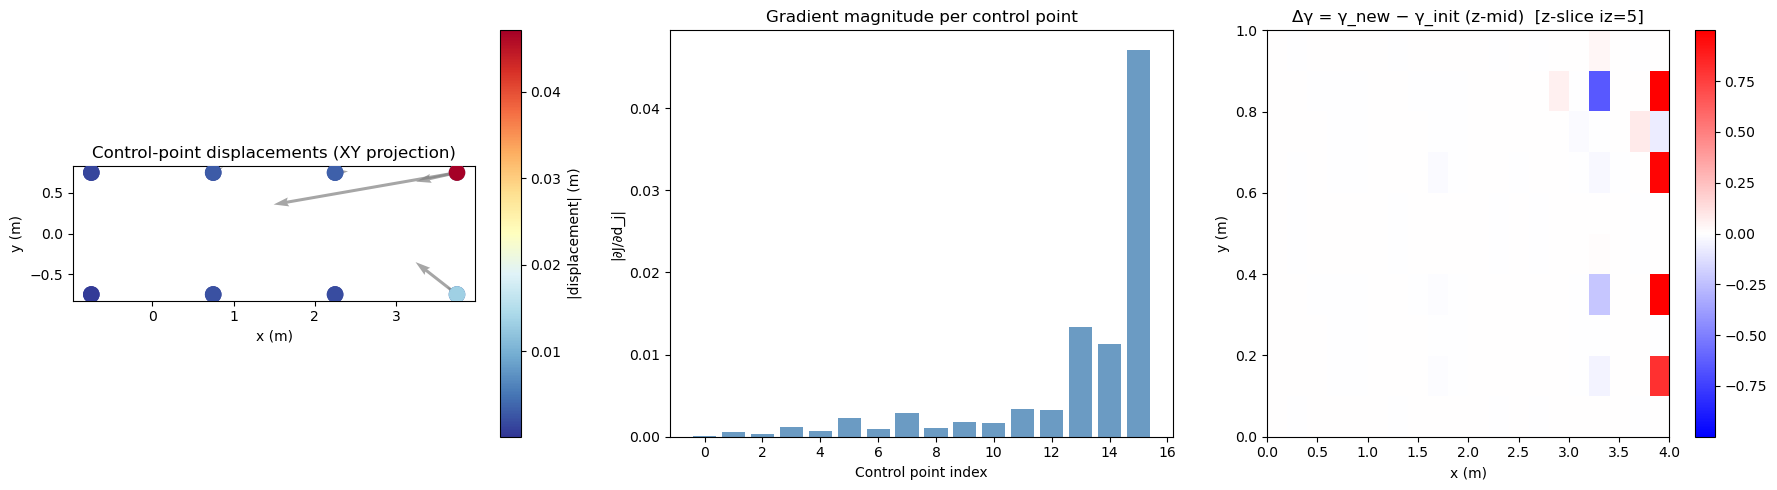

Mean |Δγ|      : 0.0324
Max |Δγ|       : 0.9999
Mean solid frac: 0.318  →  0.317


In [14]:
ctrl_disp_new_np = np.array(ctrl_dv_new).reshape(n_ctrl, 3)
ctrl_disp_grad   = np.array(grad0).reshape(n_ctrl, 3)

disp_mags = np.linalg.norm(ctrl_disp_new_np, axis=1)
grad_mags = np.linalg.norm(ctrl_disp_grad,   axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1 — displacements in XY plane
sc = axes[0].scatter(ctrl_pts[:, 0], ctrl_pts[:, 1], c=disp_mags, cmap='RdYlBu_r', s=120, zorder=5)
axes[0].quiver(ctrl_pts[:, 0], ctrl_pts[:, 1],
               ctrl_disp_new_np[:, 0], ctrl_disp_new_np[:, 1],
               color='gray', alpha=0.7)
plt.colorbar(sc, ax=axes[0], label='|displacement| (m)')
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('y (m)')
axes[0].set_title('Control-point displacements (XY projection)')
axes[0].set_aspect('equal')

# Panel 2 — gradient magnitude per control point
axes[1].bar(range(n_ctrl), grad_mags, color='steelblue', alpha=0.8)
axes[1].set_xlabel('Control point index')
axes[1].set_ylabel('|∂J/∂d_j|')
axes[1].set_title('Gradient magnitude per control point')

# Panel 3 — difference in γ (update effect on design)
delta_gamma = mat_frac_new - mat_frac_init
plot_slice(thermal_mesh, delta_gamma, 'Δγ = γ_new − γ_init (z-mid)',
           axis='z', ax=axes[2], cmap='bwr',
           vmin=-max(abs(delta_gamma.max()), abs(delta_gamma.min())),
           vmax= max(abs(delta_gamma.max()), abs(delta_gamma.min())))

plt.tight_layout()
plt.show()

print(f'Mean |Δγ|      : {np.abs(delta_gamma).mean():.4f}')
print(f'Max |Δγ|       : {np.abs(delta_gamma).max():.4f}')
print(f'Mean solid frac: {mat_frac_init.mean():.3f}  →  {mat_frac_new.mean():.3f}')

## Continuous Optimisation Loop (MMA)

Uses the **Method of Moving Asymptotes (MMA)** already implemented in TOFLUX,
with the same RAMP continuation schedule as the standard CHT topology optimisation.

**Design variables**: flattened RBF control-point displacements
$\mathbf{d} \in [-d_{\max}, d_{\max}]^{3 N_c}$ (box-constrained).

**Constraint**: keep mean solid fraction near the initial Schwarz value:
$$
g(\mathbf{d}) = 1 - \frac{\overline{\gamma}(\mathbf{d})}{\gamma^*} \le 0
\quad (\text{i.e.}\; \overline{\gamma} \ge \gamma^*)
$$

**Continuation**: RAMP penalties are gradually tightened each epoch to push
the smooth $\gamma$ field toward sharper solid/fluid regions as the
optimisation progresses.


In [ ]:
import toflux.src.mma as _mma

# ── Loop hyper-parameters ──────────────────────────────────────────────────
max_iter      = 100       # MMA iterations
move_limit    = 0.15      # MMA move limit (fraction of variable range)
kkt_tol       = 1e-4      # KKT norm convergence threshold
step_tol      = 1e-5      # step-size convergence threshold
plot_interval = 5         # plot every N epochs
max_disp      = 0.25      # m — box bound on each ctrl-pt displacement

# Volume target: keep mean gamma at least as large as the initial Schwarz value
target_gamma  = float(mat_frac_init.mean())
print(f'Volume target γ* = {target_gamma:.3f}  '
      f'(Schwarz solid fraction at d=0)')


# ── Constraint function (differentiable via JAX) ───────────────────────────
def constraint_fn(ctrl_disp_flat: jnp.ndarray):
    """Volume constraint: mean(γ) ≥ target_gamma.

    Returns g (scalar ≤ 0 when satisfied) and ∂g/∂d (shape: n_dv × 1).
    """
    def _g(d):
        return 1.0 - jnp.mean(lattice_mat_frac(d)) / target_gamma
    g, dg = jax.value_and_grad(_g)(ctrl_disp_flat)
    return jnp.array([g]), dg.reshape(1, -1)   # shape: (num_cons, n_dv) = (1, n_dv)


# ── MMA initialisation ─────────────────────────────────────────────────────
n_dv_rbf   = n_ctrl * 3
init_dv    = np.zeros((n_dv_rbf, 1))  # start from undistorted Schwarz

mma_params = _mma.MMAParams(
    max_iter       = max_iter,
    kkt_tol        = kkt_tol,
    step_tol       = step_tol,
    move_limit     = move_limit,
    num_design_var = n_dv_rbf,
    num_cons       = 1,
    lower_bound    = -max_disp * np.ones((n_dv_rbf, 1)),
    upper_bound    =  max_disp * np.ones((n_dv_rbf, 1)),
)
mma_state = _mma.init_mma(init_dv, mma_params)
history   = {'obj': [], 'vol_cons': [], 'therm_pwr': []}

# Warm-start vectors (Dirichlet BCs applied)
pv_ws = jnp.zeros(flow_solver.mesh.num_dofs)
pv_ws = pv_ws.at[flow_solver.bc['fixed_dofs']].set(
    jnp.asarray(flow_solver.bc['dirichlet_values'], dtype=jnp.float64)
)
t_ws  = jnp.zeros(thermal_solver.mesh.num_dofs)
t_ws  = t_ws.at[thermal_solver.bc['fixed_dofs']].set(
    jnp.asarray(thermal_solver.bc['dirichlet_values'], dtype=jnp.float64)
)

print(f'MMA ready: {n_dv_rbf} design variables,  '
      f'bounds [{-max_disp}, {max_disp}] m')


Volume target γ* = 0.318  (Schwarz solid fraction at d=0)
MMA ready: 48 design variables,  bounds [-0.25, 0.25] m


Starting MMA optimisation  (max_iter=100, move_limit=0.15, kkt_tol=0.0001)
 epoch           J           g    Q_th (W)    ramp_f    ramp_t
----------------------------------------------------------------
NR converged in 4 iters, res_norm/res_norm_0: 2.8835823912137815e-12
NR converged in 2 iters, res_norm/res_norm_0: 5.761485734113133e-15
     0  6.3128e-03  0.0000e+00       48.85     98.00     0.010


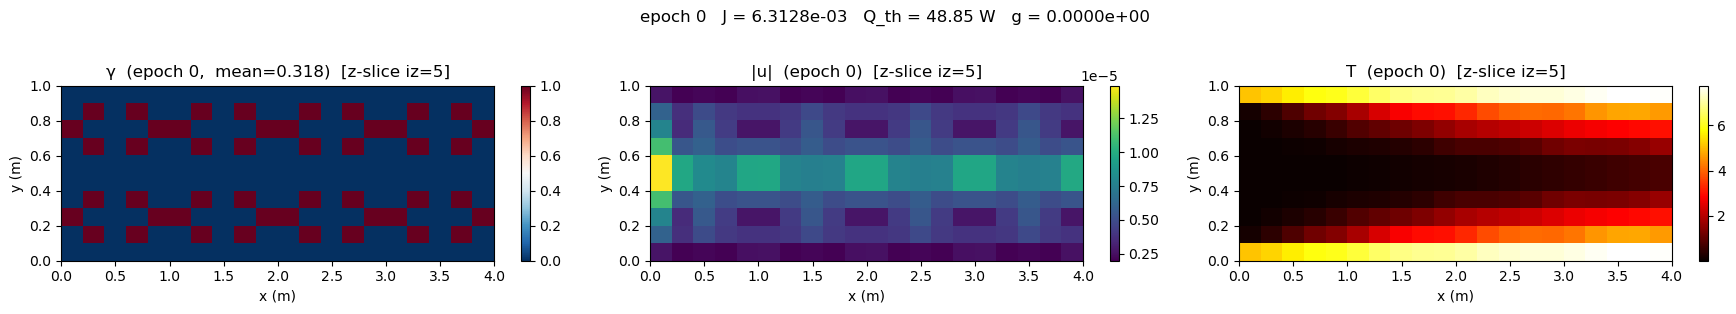

NR converged in 4 iters, res_norm/res_norm_0: 4.922291199070001e-13
NR converged in 2 iters, res_norm/res_norm_0: 4.117016664546212e-15
     1  3.9695e-03  9.1658e-02       80.38     97.67     0.018


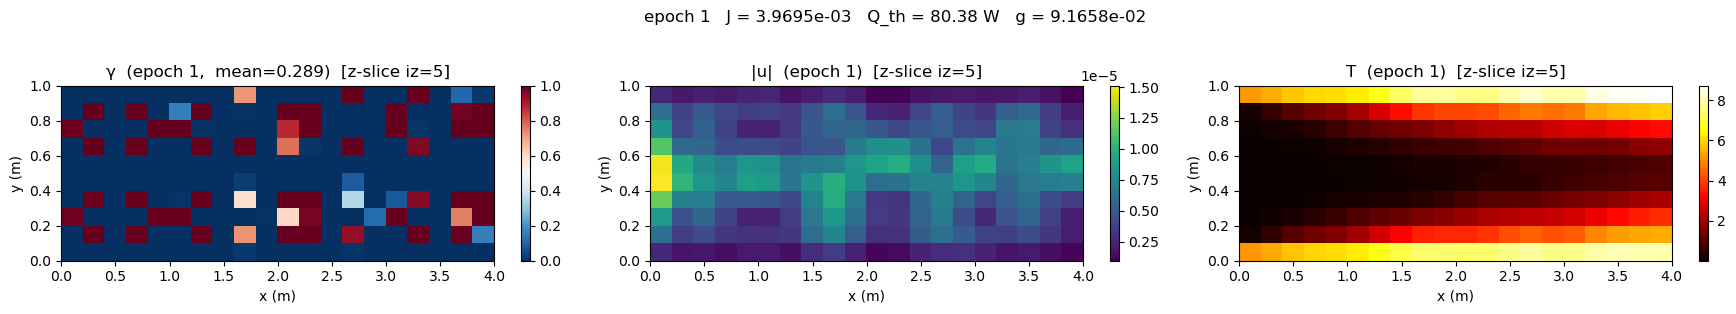

NR converged in 4 iters, res_norm/res_norm_0: 9.142106361597403e-15
NR converged in 2 iters, res_norm/res_norm_0: 2.4381960960321334e-15
     2  4.1073e-03  9.8184e-02       77.61     96.69     0.026
NR converged in 4 iters, res_norm/res_norm_0: 1.084524803399811e-14
NR converged in 2 iters, res_norm/res_norm_0: 3.366951499754687e-15
     3  4.1005e-03  1.0811e-01       78.79     95.11     0.034
NR converged in 4 iters, res_norm/res_norm_0: 6.973549262276618e-15
NR converged in 2 iters, res_norm/res_norm_0: 2.043671881764069e-15
     4  4.4990e-03  8.2918e-02       71.03     92.98     0.042
NR converged in 4 iters, res_norm/res_norm_0: 3.6763262392010876e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.4662007105442797e-15
     5  4.0940e-03  8.6319e-02       77.56     90.37     0.050


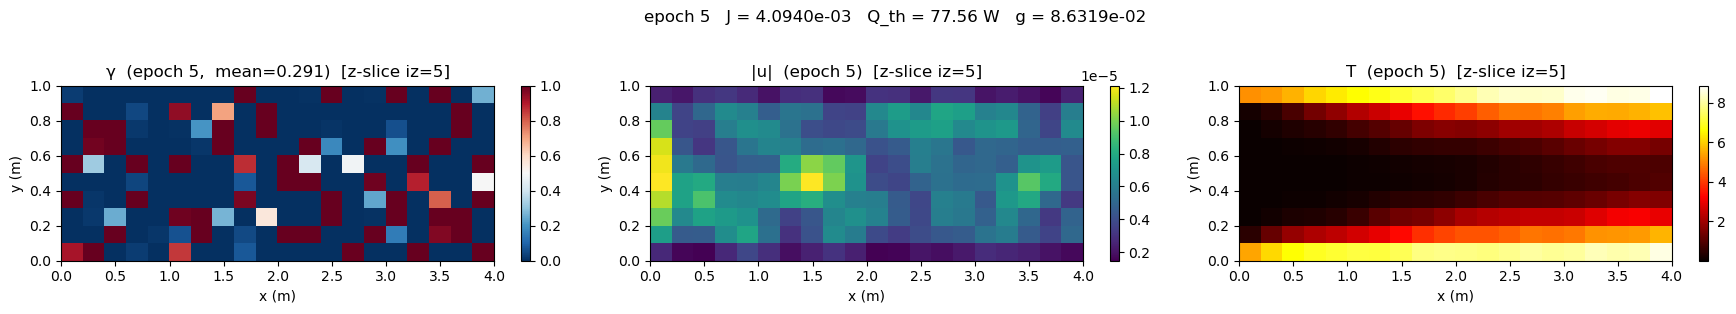

NR converged in 4 iters, res_norm/res_norm_0: 9.222642194955802e-15
NR converged in 2 iters, res_norm/res_norm_0: 2.122237833938391e-15
     6  3.8781e-03  8.9591e-02       80.85     87.38     0.058
NR converged in 4 iters, res_norm/res_norm_0: 3.983780496539109e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.044977931328561e-15
     7  4.5387e-03  5.5424e-02       72.51     84.08     0.066
NR converged in 4 iters, res_norm/res_norm_0: 1.1214217573016951e-14
NR converged in 2 iters, res_norm/res_norm_0: 1.881484371516112e-15
     8  4.6456e-03  7.6124e-02       69.79     80.58     0.074
NR converged in 4 iters, res_norm/res_norm_0: 7.772330524325167e-14
NR converged in 2 iters, res_norm/res_norm_0: 3.313338827172006e-15
     9  4.1370e-03  6.6496e-02       77.78     76.95     0.082
NR converged in 4 iters, res_norm/res_norm_0: 9.571843302506187e-15
NR converged in 2 iters, res_norm/res_norm_0: 2.340660234239441e-15
    10  4.4262e-03  7.6262e-02       73.70     73.26     0.090


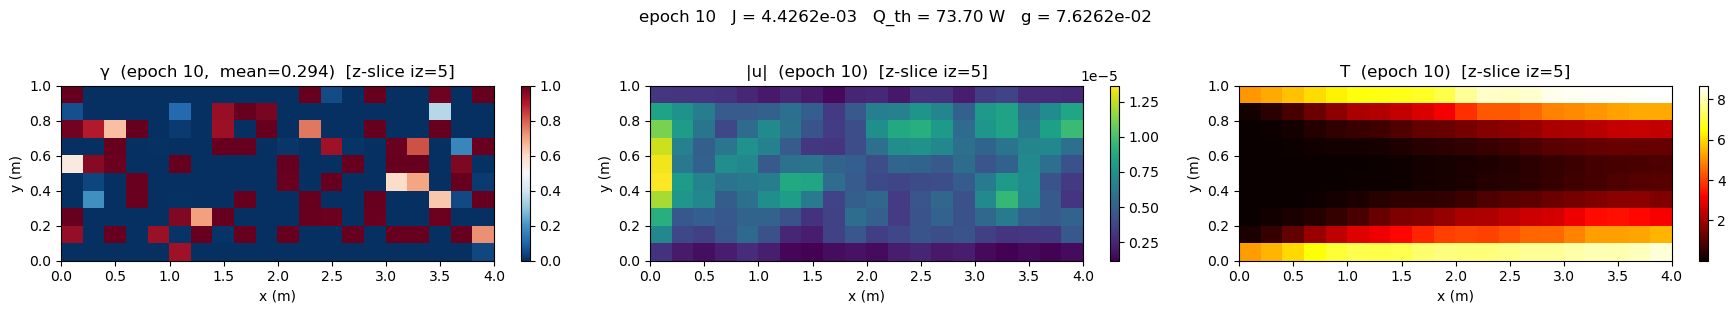

NR converged in 4 iters, res_norm/res_norm_0: 1.428224879460961e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.4955666304242362e-15
    11  4.1783e-03  7.2273e-02       77.76     69.57     0.098
NR converged in 4 iters, res_norm/res_norm_0: 8.241747762060155e-15
NR converged in 2 iters, res_norm/res_norm_0: 2.2263330168896562e-15
    12  4.3721e-03  7.0511e-02       73.98     65.93     0.106
NR converged in 4 iters, res_norm/res_norm_0: 1.0472378366186433e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.24776389488648e-15
    13  4.8308e-03  7.1158e-02       66.89     62.39     0.114
NR converged in 4 iters, res_norm/res_norm_0: 1.5332884170985223e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.5357024217953888e-15
    14  5.5348e-03  6.8536e-02       57.45     58.96     0.122
NR converged in 4 iters, res_norm/res_norm_0: 1.0586767037612025e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.856678133084106e-15
    15  4.9610e-03  7.6276e-02       66.00     55.68     0.130


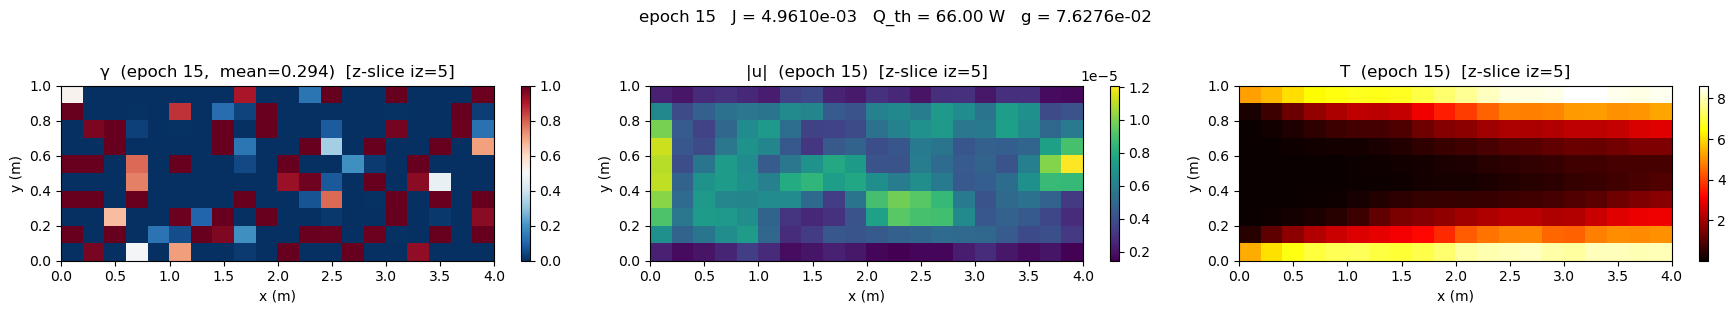

NR converged in 4 iters, res_norm/res_norm_0: 1.047817801915592e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.902165862599765e-15
    16  5.1485e-03  7.7059e-02       62.85     52.56     0.138
NR converged in 4 iters, res_norm/res_norm_0: 2.861772887882559e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.9216457059401613e-15
    17  4.8757e-03  9.2998e-02       66.67     49.59     0.146
NR converged in 4 iters, res_norm/res_norm_0: 1.2157917707978646e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.437221171069263e-15
    18  5.1054e-03  7.8607e-02       63.19     46.79     0.154
NR converged in 4 iters, res_norm/res_norm_0: 1.0292269016378985e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.103308671537033e-15
    19  5.0155e-03  7.9166e-02       65.52     44.16     0.162
NR converged in 4 iters, res_norm/res_norm_0: 1.0488296341284473e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.454139408086594e-15
    20  5.3411e-03  6.0944e-02       61.18     41.68     0.170


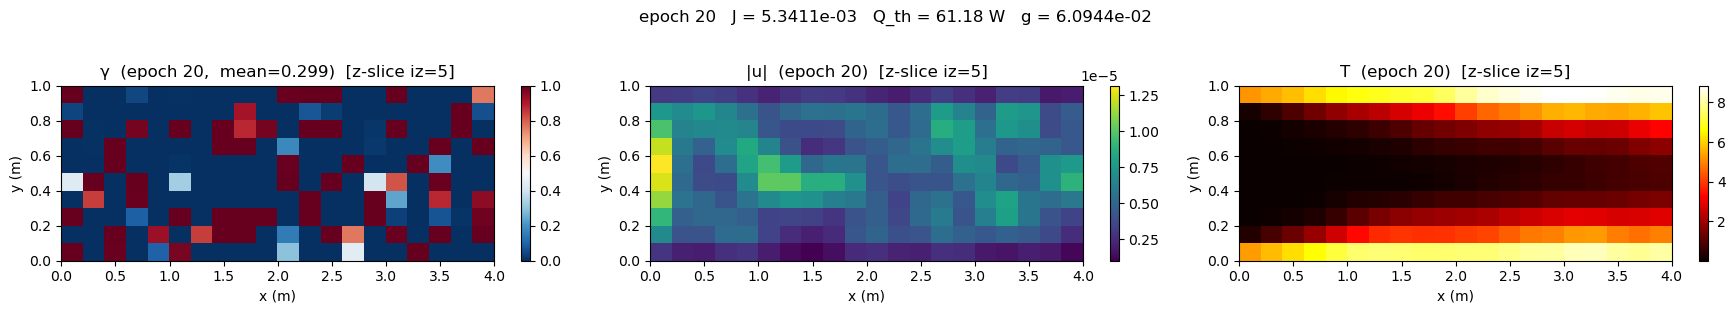

NR converged in 4 iters, res_norm/res_norm_0: 1.1061508233894335e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.2797460092303628e-15
    21  5.4046e-03  4.2809e-02       60.66     39.36     0.178
NR converged in 4 iters, res_norm/res_norm_0: 1.2189948701141593e-14
NR converged in 2 iters, res_norm/res_norm_0: 1.8782181722807116e-15
    22  5.2337e-03  5.8540e-02       62.11     37.19     0.186
NR converged in 4 iters, res_norm/res_norm_0: 1.083719896746806e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.3362008422516715e-15
    23  5.1692e-03  5.5381e-02       62.35     35.17     0.194
NR converged in 4 iters, res_norm/res_norm_0: 7.350745926718257e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.658830690329246e-15
    24  5.1427e-03  4.5052e-02       64.02     33.27     0.202
NR converged in 4 iters, res_norm/res_norm_0: 1.2228984903349546e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.3206297511042034e-15
    25  5.0840e-03  4.8229e-02       64.31     31.50     0.21

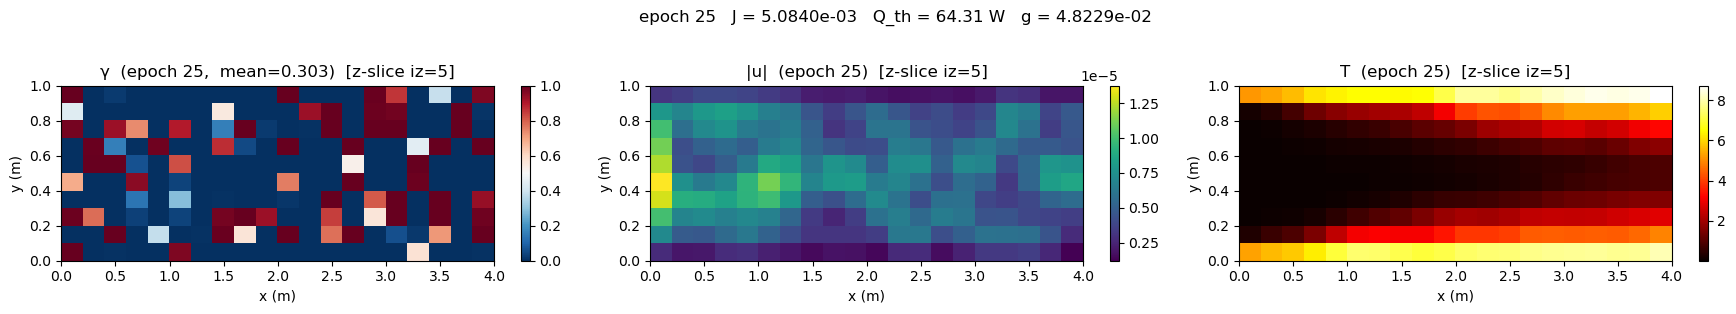

NR converged in 4 iters, res_norm/res_norm_0: 1.406046708238429e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.3675853618111023e-15
    26  5.2595e-03  4.7853e-02       62.13     29.85     0.218
NR converged in 4 iters, res_norm/res_norm_0: 1.3252703875113139e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.10535238924009e-15
    27  5.2135e-03  4.1483e-02       62.91     28.30     0.226
NR converged in 4 iters, res_norm/res_norm_0: 1.5013405205634675e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.2807733828352848e-15
    28  5.1826e-03  2.8965e-02       63.72     26.86     0.234
NR converged in 4 iters, res_norm/res_norm_0: 1.7559741067184108e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.1169236125137165e-15
    29  5.2918e-03  2.6612e-02       62.26     25.52     0.242
NR converged in 4 iters, res_norm/res_norm_0: 2.5468487780339565e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.3336540913974797e-15
    30  5.1198e-03  1.5576e-02       64.97     24.26     0.25

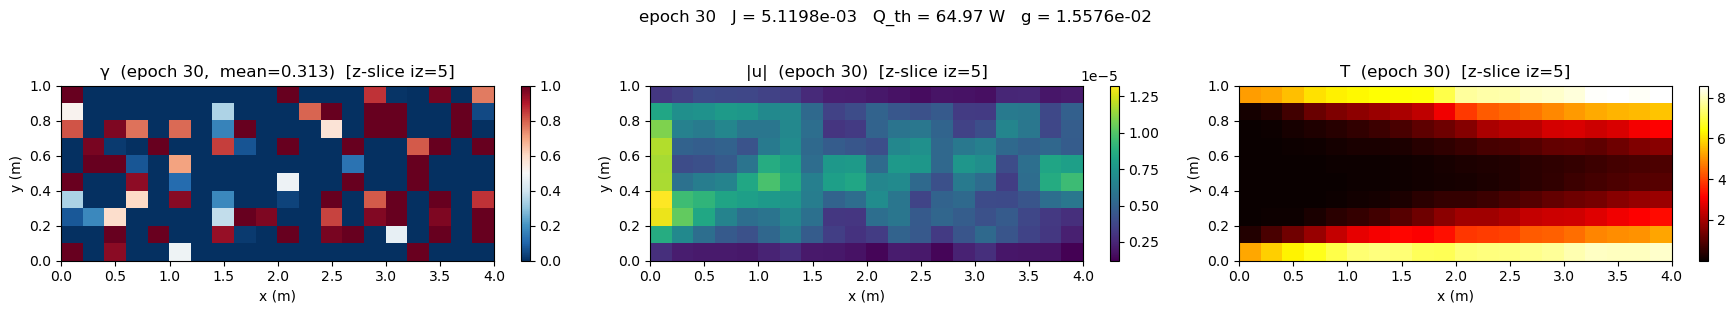

NR converged in 4 iters, res_norm/res_norm_0: 2.5585253345622806e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.7516418750353287e-15
    31  5.1847e-03  1.8602e-02       64.23     23.08     0.258
NR converged in 4 iters, res_norm/res_norm_0: 3.1502099610715595e-14
NR converged in 2 iters, res_norm/res_norm_0: 3.131958830620098e-15
    32  5.1444e-03  9.1748e-03       65.00     21.98     0.266
NR converged in 4 iters, res_norm/res_norm_0: 4.320402582092273e-14
NR converged in 2 iters, res_norm/res_norm_0: 4.64394730532775e-15
    33  5.2427e-03  6.9800e-03       63.80     20.95     0.274
NR converged in 4 iters, res_norm/res_norm_0: 4.914921901134018e-14
NR converged in 2 iters, res_norm/res_norm_0: 3.7107033280705586e-15
    34  5.1484e-03  4.1264e-03       65.25     19.98     0.282
NR converged in 4 iters, res_norm/res_norm_0: 6.678576168232478e-14
NR converged in 2 iters, res_norm/res_norm_0: 5.4175621948679944e-15
    35  5.1603e-03  1.7957e-03       65.23     19.07     0.290


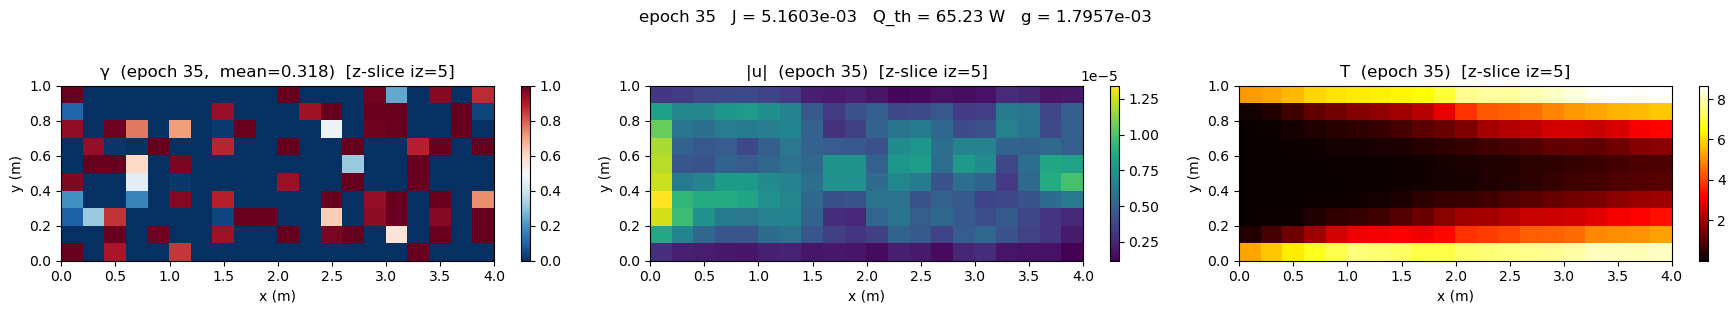

NR converged in 3 iters, res_norm/res_norm_0: 8.113306153386144e-10
NR converged in 2 iters, res_norm/res_norm_0: 5.9205783191619425e-15
    36  5.1028e-03  4.1290e-04       66.13     18.22     0.298
NR converged in 3 iters, res_norm/res_norm_0: 1.5902203206148766e-10
NR converged in 2 iters, res_norm/res_norm_0: 1.2989397168481458e-14
    37  5.0799e-03  -9.6990e-05       66.53     17.42     0.300
NR converged in 4 iters, res_norm/res_norm_0: 1.0055413545055541e-13
NR converged in 2 iters, res_norm/res_norm_0: 9.715321066758604e-15
    38  5.0641e-03  1.0881e-03       66.73     16.67     0.300
NR converged in 4 iters, res_norm/res_norm_0: 1.2634890282125673e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.1662884544411699e-14
    39  5.0772e-03  -9.6495e-05       66.62     15.97     0.300
NR converged in 3 iters, res_norm/res_norm_0: 5.752103245075604e-10
NR converged in 2 iters, res_norm/res_norm_0: 1.2016577478113786e-14
    40  5.0519e-03  1.8430e-04       67.05     15.30     0.

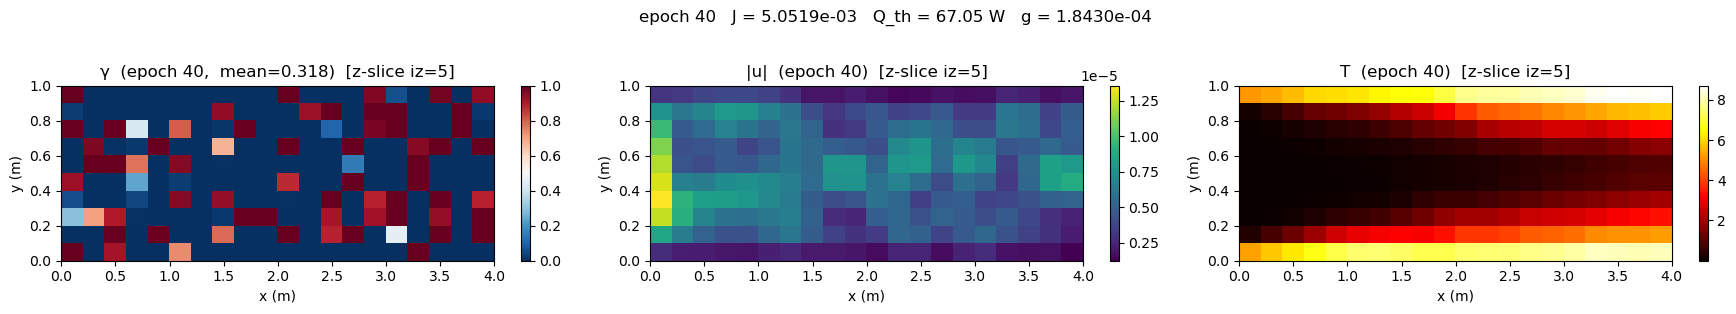

NR converged in 3 iters, res_norm/res_norm_0: 2.4365425081750724e-10
NR converged in 2 iters, res_norm/res_norm_0: 1.2735654484157315e-14
    41  5.0525e-03  1.6671e-04       67.06     14.67     0.300
NR converged in 3 iters, res_norm/res_norm_0: 1.7344136553414279e-10
NR converged in 2 iters, res_norm/res_norm_0: 1.320099783187276e-14
    42  5.0406e-03  1.6682e-05       67.30     14.08     0.300
NR converged in 3 iters, res_norm/res_norm_0: 9.598064331838236e-11
NR converged in 2 iters, res_norm/res_norm_0: 1.2847963986606846e-14
    43  5.0325e-03  -6.5802e-05       67.45     13.53     0.300
NR converged in 3 iters, res_norm/res_norm_0: 1.031630836982102e-10
NR converged in 2 iters, res_norm/res_norm_0: 1.584814616535008e-14
    44  5.0237e-03  -9.9706e-05       67.62     13.00     0.300
NR converged in 3 iters, res_norm/res_norm_0: 7.849713227012077e-11
NR converged in 2 iters, res_norm/res_norm_0: 1.4021346592200383e-14
    45  5.0125e-03  -1.3646e-04       67.83     12.50     0.3

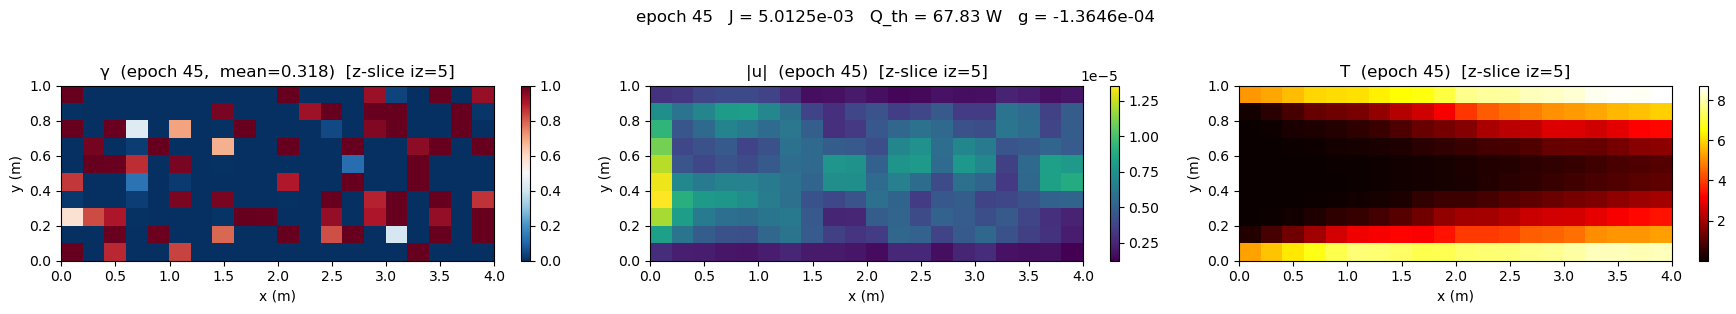

NR converged in 3 iters, res_norm/res_norm_0: 2.5966416983264236e-10
NR converged in 2 iters, res_norm/res_norm_0: 1.674323798891035e-14
    46  5.0018e-03  -1.8005e-04       68.01     12.03     0.300
NR converged in 3 iters, res_norm/res_norm_0: 1.78898115570937e-10
NR converged in 2 iters, res_norm/res_norm_0: 1.473506300171802e-14
    47  4.9902e-03  -1.1367e-04       68.24     11.58     0.300
NR converged in 3 iters, res_norm/res_norm_0: 2.5454707403357916e-10
NR converged in 2 iters, res_norm/res_norm_0: 1.784898666502464e-14
    48  4.9808e-03  -2.1037e-04       68.42     11.16     0.300
NR converged in 3 iters, res_norm/res_norm_0: 2.897001418106193e-10
NR converged in 2 iters, res_norm/res_norm_0: 1.7700352916387625e-14
    49  4.9736e-03  -6.2926e-05       68.55     10.76     0.300
NR converged in 3 iters, res_norm/res_norm_0: 3.0408699942675536e-10
NR converged in 2 iters, res_norm/res_norm_0: 1.2601174473867286e-14
    50  4.9733e-03  1.4185e-04       68.65     10.38     0.3

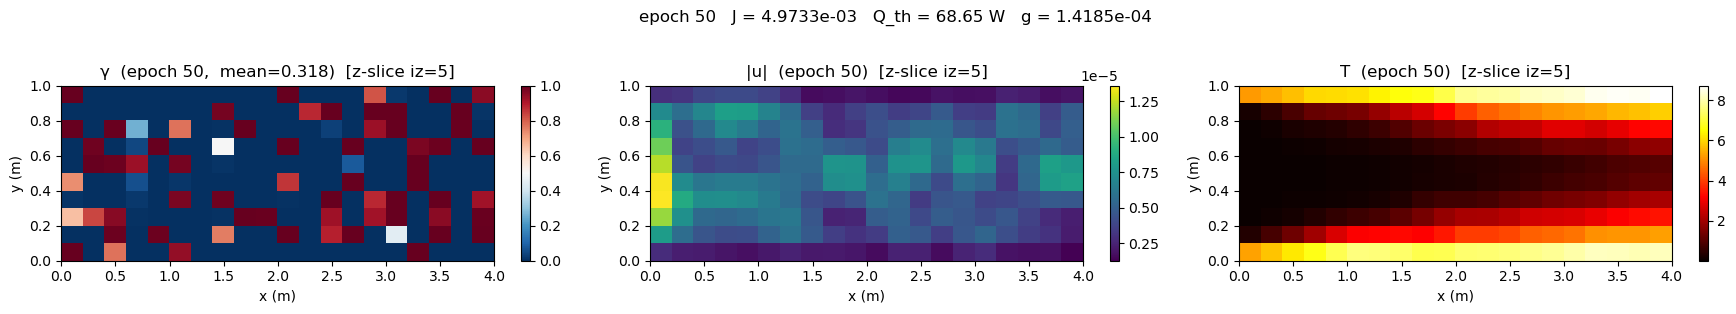

NR converged in 4 iters, res_norm/res_norm_0: 7.043848851291938e-14
NR converged in 2 iters, res_norm/res_norm_0: 7.881777713073515e-15
    51  4.9663e-03  1.3756e-03       68.66     10.01     0.300
NR converged in 4 iters, res_norm/res_norm_0: 5.075340146326884e-14
NR converged in 2 iters, res_norm/res_norm_0: 4.977588148191154e-15
    52  4.9726e-03  2.7545e-03       69.00      9.67     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.9693309155334066e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.943466045985982e-15
    53  5.0472e-03  3.0942e-03       67.59      9.34     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.5259520764745038e-14
NR converged in 2 iters, res_norm/res_norm_0: 2.7846284510361865e-15
    54  4.9868e-03  9.5330e-03       68.63      9.03     0.300
NR converged in 4 iters, res_norm/res_norm_0: 3.084651307939746e-14
NR converged in 2 iters, res_norm/res_norm_0: 3.2730079774270444e-15
    55  5.0462e-03  -2.2269e-04       68.04      8.74     0.300


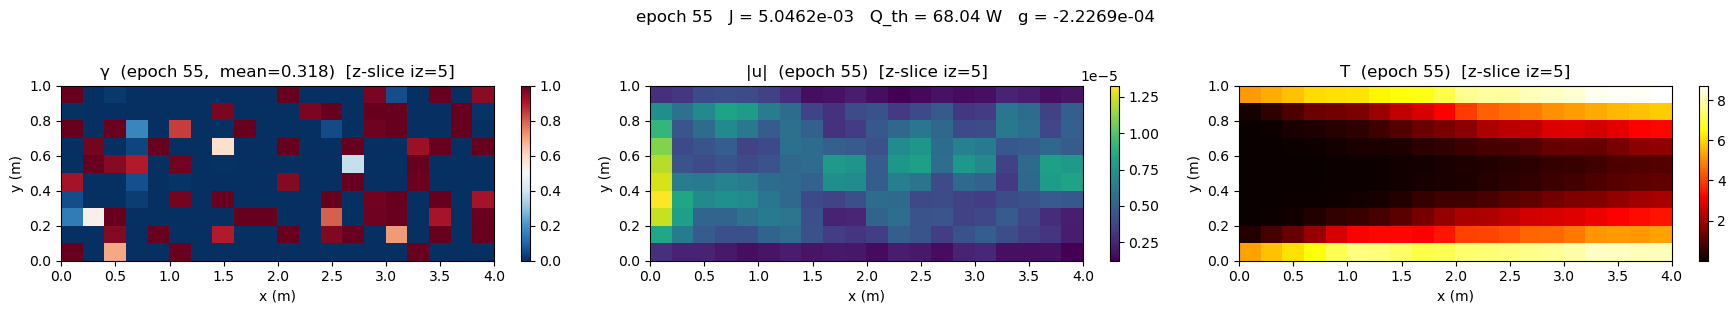

NR converged in 4 iters, res_norm/res_norm_0: 4.3717846150198377e-14
NR converged in 2 iters, res_norm/res_norm_0: 4.258610519629935e-15
    56  4.9481e-03  3.0207e-03       69.13      8.45     0.300
NR converged in 3 iters, res_norm/res_norm_0: 9.682761283414779e-10
NR converged in 2 iters, res_norm/res_norm_0: 7.145085283848191e-15
    57  4.9641e-03  -6.4111e-04       69.01      8.18     0.300
NR converged in 3 iters, res_norm/res_norm_0: 4.946178874846976e-10
NR converged in 2 iters, res_norm/res_norm_0: 8.093091268587958e-15
    58  4.9502e-03  7.0360e-06       69.25      7.93     0.300
NR converged in 4 iters, res_norm/res_norm_0: 6.316541740795364e-14
NR converged in 2 iters, res_norm/res_norm_0: 4.9137633701889974e-15
    59  4.9614e-03  5.5614e-04       69.07      7.68     0.300
NR converged in 4 iters, res_norm/res_norm_0: 6.045290795141487e-14
NR converged in 2 iters, res_norm/res_norm_0: 4.027598796719779e-15
    60  4.9422e-03  1.8056e-03       69.33      7.45     0.300


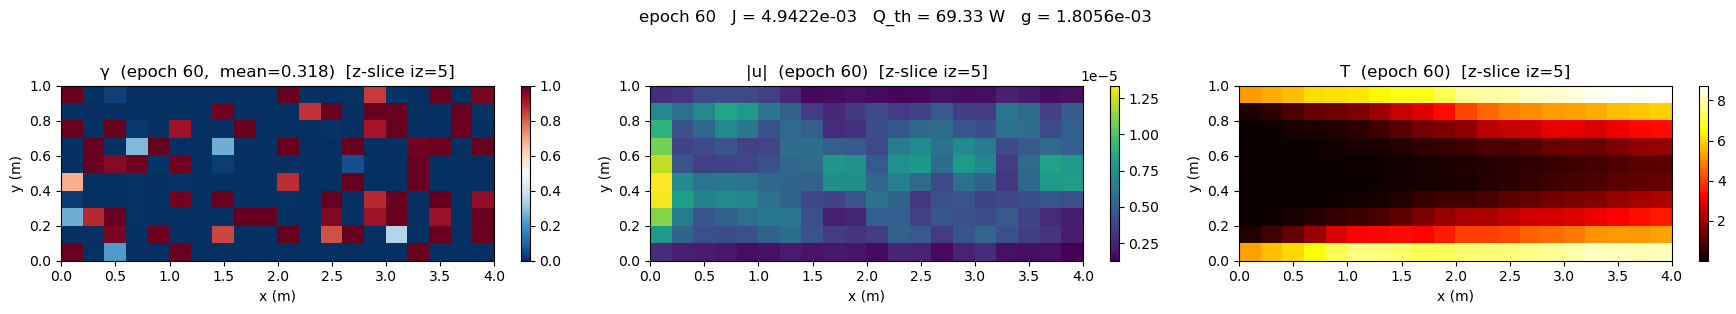

NR converged in 4 iters, res_norm/res_norm_0: 8.073957830551434e-14
NR converged in 2 iters, res_norm/res_norm_0: 7.129912323170524e-15
    61  4.9461e-03  -1.1101e-07       69.33      7.22     0.300
NR converged in 3 iters, res_norm/res_norm_0: 5.544942905766051e-10
NR converged in 2 iters, res_norm/res_norm_0: 9.789249358761515e-15
    62  4.9381e-03  1.2417e-04       69.51      7.01     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.1467813072890992e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.60627883169633e-14
    63  4.9411e-03  -1.0748e-04       69.47      6.80     0.300
NR converged in 3 iters, res_norm/res_norm_0: 5.0333506666414e-10
NR converged in 2 iters, res_norm/res_norm_0: 1.958626837061207e-14
    64  4.9282e-03  -4.6206e-05       69.70      6.61     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.9997899762723295e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.1085262065993553e-14
    65  4.9377e-03  -2.2257e-04       69.58      6.42     0.300


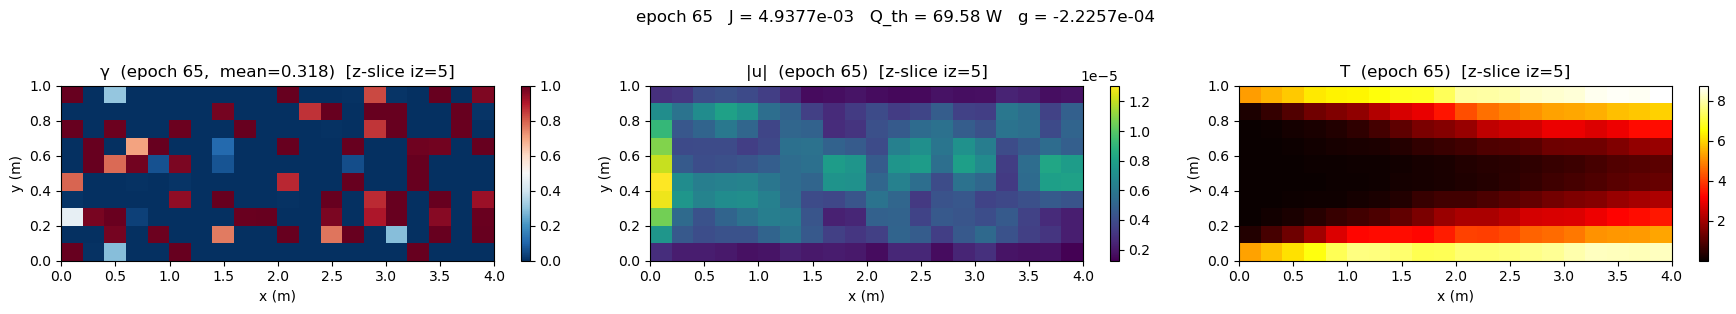

NR converged in 4 iters, res_norm/res_norm_0: 2.7251074196530456e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.8418911253193562e-14
    66  4.9258e-03  -1.9214e-04       69.78      6.24     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.7893097044483876e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.99244752811922e-14
    67  4.9345e-03  -2.7169e-04       69.67      6.06     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.329279134170423e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.833241009877217e-14
    68  4.9302e-03  -2.1431e-04       69.79      5.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 1.7284504325052544e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.5611581476495818e-14
    69  4.9372e-03  -3.0262e-04       69.69      5.74     0.300
NR converged in 4 iters, res_norm/res_norm_0: 1.523617748234811e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.5256385909185184e-14
    70  4.9333e-03  -2.1301e-04       69.80      5.58     0

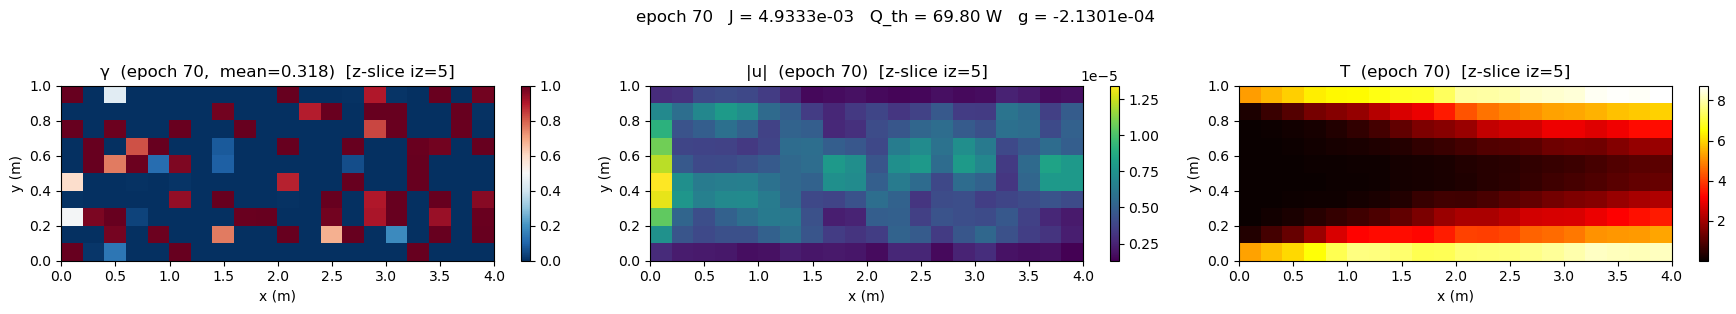

NR converged in 4 iters, res_norm/res_norm_0: 2.303926989105353e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.8154852500409177e-14
    71  4.9353e-03  -2.7399e-04       69.77      5.44     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.7969014973368634e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.2515662801266737e-14
    72  4.9342e-03  -1.6795e-04       69.82      5.29     0.300
NR converged in 4 iters, res_norm/res_norm_0: 3.0276539872023966e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.1266396975404272e-14
    73  4.9373e-03  -2.3402e-04       69.78      5.16     0.300
NR converged in 3 iters, res_norm/res_norm_0: 9.117953027670343e-10
NR converged in 2 iters, res_norm/res_norm_0: 1.957146160935375e-14
    74  4.9305e-03  -1.1696e-04       69.93      5.03     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.8540483976110966e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.2166612465396742e-14
    75  4.9395e-03  -2.3814e-04       69.81      4.90    

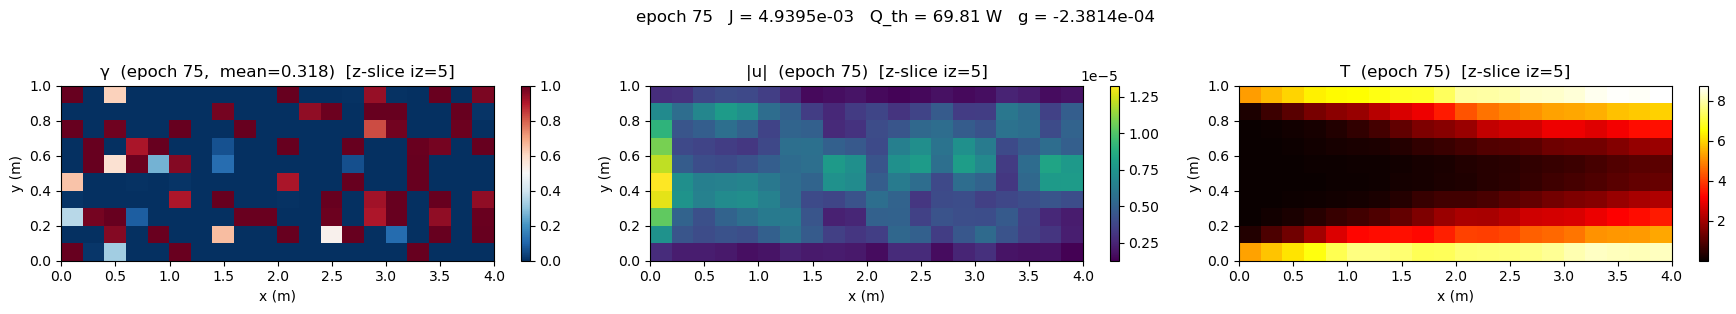

NR converged in 4 iters, res_norm/res_norm_0: 2.432574576792105e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.9102503821401537e-14
    76  4.9286e-03  -1.9634e-04       69.99      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.762452310907779e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.0698854378180777e-14
    77  4.9331e-03  -3.4125e-04       69.93      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.146874729212004e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.9153566456664097e-14
    78  4.9259e-03  -2.2840e-04       70.03      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.2564578668983058e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.7462605792981445e-14
    79  4.9334e-03  -2.5514e-04       69.88      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.0779495365557696e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.186330400292173e-14
    80  4.9245e-03  -2.8453e-04       70.06      4.90     

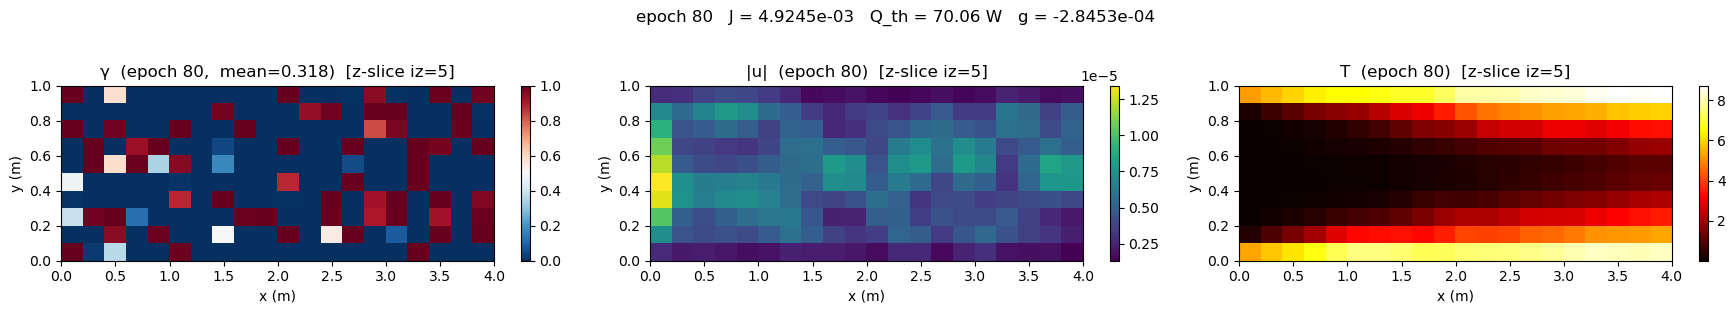

NR converged in 4 iters, res_norm/res_norm_0: 2.3637421439544175e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.998184903469078e-14
    81  4.9263e-03  -2.5650e-04       69.98      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.046991439766868e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.9019591890996593e-14
    82  4.9221e-03  -2.4867e-04       70.10      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.2600837848752507e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.9786611738491516e-14
    83  4.9239e-03  -2.3037e-04       70.02      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.453211415080214e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.1100399013749407e-14
    84  4.9185e-03  -1.2938e-04       70.14      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.705381864591221e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.3144781406335825e-14
    85  4.9220e-03  -1.4620e-04       70.05      4.90     

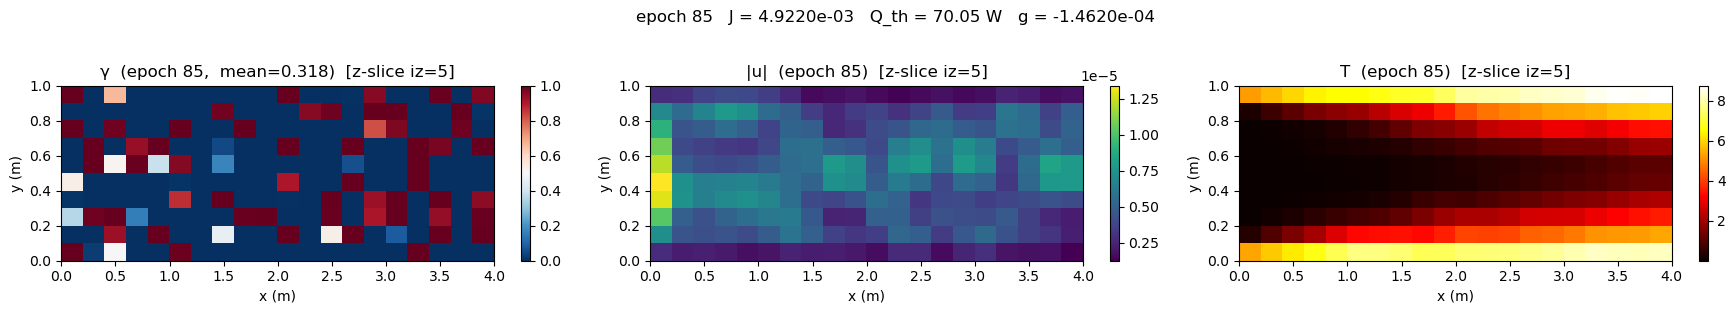

NR converged in 4 iters, res_norm/res_norm_0: 2.559135547954999e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.9683398552580512e-14
    86  4.9164e-03  -1.0191e-04       70.17      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.5606449435958575e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.0443246116355616e-14
    87  4.9206e-03  -1.3291e-04       70.07      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.477320107625993e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.1623023839665455e-14
    88  4.9148e-03  -1.1764e-04       70.20      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.327151726342229e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.073708446411435e-14
    89  4.9190e-03  -1.3469e-04       70.10      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.405024886388307e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.968357629013415e-14
    90  4.9134e-03  -1.3207e-04       70.22      4.90     0.

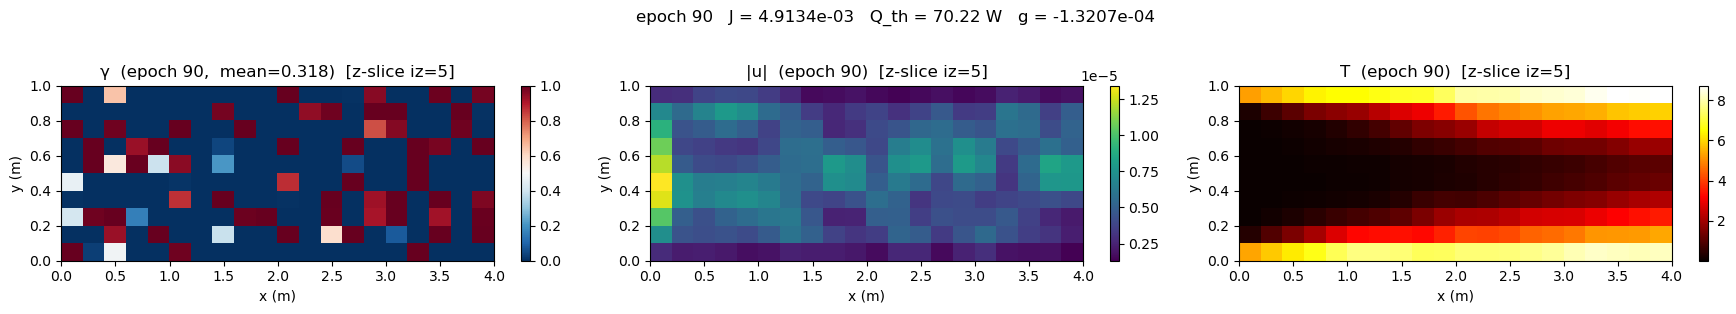

NR converged in 4 iters, res_norm/res_norm_0: 2.443331830149494e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.2152786903542032e-14
    91  4.9171e-03  -1.3360e-04       70.13      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.442647840582979e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.0783072775210645e-14
    92  4.9118e-03  -1.0963e-04       70.24      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.3740429630173524e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.2097440039702788e-14
    93  4.9164e-03  -1.1736e-04       70.14      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.0261203832013963e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.874877912707286e-14
    94  4.9188e-03  -9.3689e-05       70.13      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.0462183568669392e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.2721810468750148e-14
    95  4.9162e-03  -7.3604e-05       70.14      4.90    

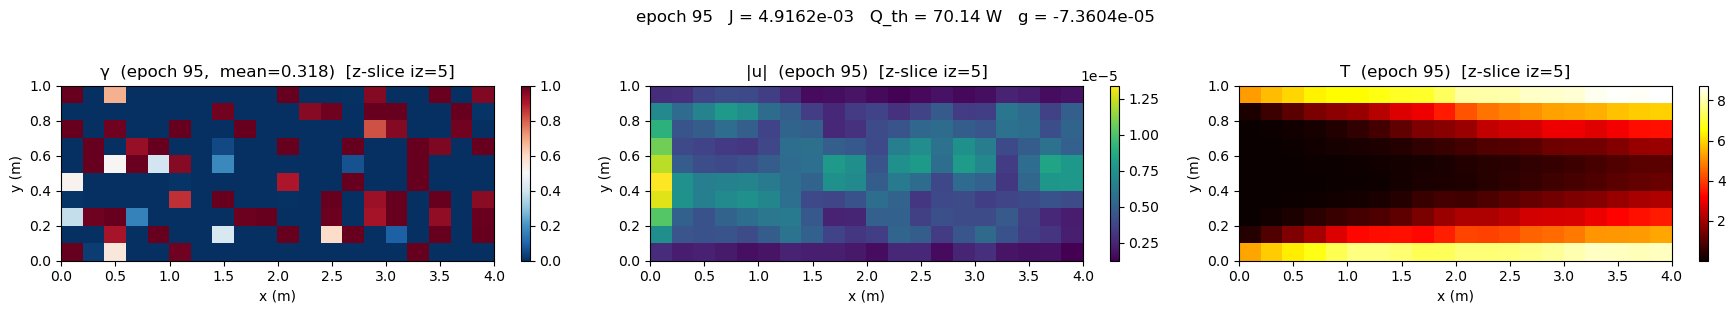

NR converged in 4 iters, res_norm/res_norm_0: 2.2166752209780803e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.50813849910981e-14
    96  4.9129e-03  -1.7267e-04       70.22      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.4595158722914206e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.420053431955188e-14
    97  4.9139e-03  -1.6056e-04       70.18      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.322515227815143e-13
NR converged in 2 iters, res_norm/res_norm_0: 2.1399096850647288e-14
    98  4.9096e-03  -1.0796e-04       70.27      4.90     0.300
NR converged in 4 iters, res_norm/res_norm_0: 2.326321468178719e-13
NR converged in 2 iters, res_norm/res_norm_0: 1.8342899972284788e-14
    99  4.9132e-03  -1.3769e-04       70.19      4.90     0.300

Optimisation finished at epoch 100
  Final J      : 4.9132e-03
  Final Q_th   : 70.19 W
  Final g      : -1.3769e-04


In [16]:
print(f'Starting MMA optimisation  (max_iter={max_iter}, '
      f'move_limit={move_limit}, kkt_tol={kkt_tol})')
print(f'{"epoch":>6}  {"J":>10}  {"g":>10}  {"Q_th (W)":>10}  '
      f'{"ramp_f":>8}  {"ramp_t":>8}')
print('-' * 64)

while not mma_state.is_converged:
    epoch = mma_state.epoch

    # ── Continuation schedule (same as standard CHT topopt) ───────────────
    cont_param      = min(20.0, 1.0 + 19.0 * (epoch / 75.0) ** 2)
    fluid_ramp_ep   = init_ramp_penalty / cont_param
    thermal_ramp_ep = min(0.3, 0.01 + epoch * 8e-3)

    ctrl_dv_ep = mma_state.x.ravel()  # (n_dv_rbf,)

    # ── Forward pass + gradient ────────────────────────────────────────────
    (obj_ep, grad_ep, elem_pv_ep, temp_ep,
     pv_ep, t_ep, therm_ep, nth_ep, ndiss_ep) = forward_and_grad(
        ctrl_dv_ep, flow_solver, thermal_solver,
        fluid_ramp_ep, thermal_ramp_ep, pv_ws, t_ws,
    )

    # ── Volume constraint ──────────────────────────────────────────────────
    cons_ep, grad_cons_ep = constraint_fn(ctrl_dv_ep)

    # ── Warm-start next iteration from current solution ────────────────────
    pv_ws = jax.lax.stop_gradient(pv_ep)
    pv_ws = pv_ws.at[flow_solver.bc['fixed_dofs']].set(
        flow_solver.bc['dirichlet_values']
    )
    t_ws = jax.lax.stop_gradient(t_ep)
    t_ws = t_ws.at[thermal_solver.bc['fixed_dofs']].set(
        thermal_solver.bc['dirichlet_values']
    )

    # ── MMA update ────────────────────────────────────────────────────────
    mma_state = _mma.update_mma(
        mma_state, mma_params,
        obj_ep, grad_ep.reshape(-1, 1),
        cons_ep, grad_cons_ep,
    )

    # ── Track history ─────────────────────────────────────────────────────
    history['obj'].append(float(obj_ep))
    history['vol_cons'].append(float(cons_ep[0]))
    history['therm_pwr'].append(float(therm_ep))

    # ── Log ───────────────────────────────────────────────────────────────
    print(f'{epoch:6d}  {float(obj_ep):10.4e}  {float(cons_ep[0]):10.4e}  '
          f'{float(therm_ep):10.2f}  {fluid_ramp_ep:8.2f}  {thermal_ramp_ep:8.3f}')

    # ── Periodic plots ────────────────────────────────────────────────────
    if epoch % plot_interval == 0 or epoch == 1:
        dof     = flow_solver.mesh.nodes.dof_per_node
        u_ep    = np.mean(np.array(elem_pv_ep[:, 1::dof]), axis=1)
        v_ep    = np.mean(np.array(elem_pv_ep[:, 2::dof]), axis=1)
        w_ep    = np.mean(np.array(elem_pv_ep[:, 3::dof]), axis=1)
        vel_ep  = np.sqrt(u_ep**2 + v_ep**2 + w_ep**2)
        gamma_ep = np.array(lattice_mat_frac(jnp.array(ctrl_dv_ep)))

        fig, axes = plt.subplots(1, 3, figsize=(18, 3))
        plot_slice(
            thermal_mesh, gamma_ep,
            f'γ  (epoch {epoch},  mean={gamma_ep.mean():.3f})',
            axis='z', ax=axes[0], cmap='RdBu_r', vmin=0, vmax=1,
        )
        plot_slice(
            fluid_mesh, vel_ep,
            f'|u|  (epoch {epoch})',
            axis='z', ax=axes[1], cmap='viridis',
        )
        plot_slice(
            thermal_mesh, np.array(temp_ep),
            f'T  (epoch {epoch})',
            axis='z', ax=axes[2], cmap='hot',
        )
        plt.suptitle(
            f'epoch {epoch}   J = {float(obj_ep):.4e}   '
            f'Q_th = {float(therm_ep):.2f} W   g = {float(cons_ep[0]):.4e}',
            y=1.03,
        )
        plt.tight_layout()
        plt.show()

print()
print(f'Optimisation finished at epoch {mma_state.epoch}')
print(f'  Final J      : {history["obj"][-1]:.4e}')
print(f'  Final Q_th   : {history["therm_pwr"][-1]:.2f} W')
print(f'  Final g      : {history["vol_cons"][-1]:.4e}')


## Post-Processing

Convergence history and final optimised lattice geometry.

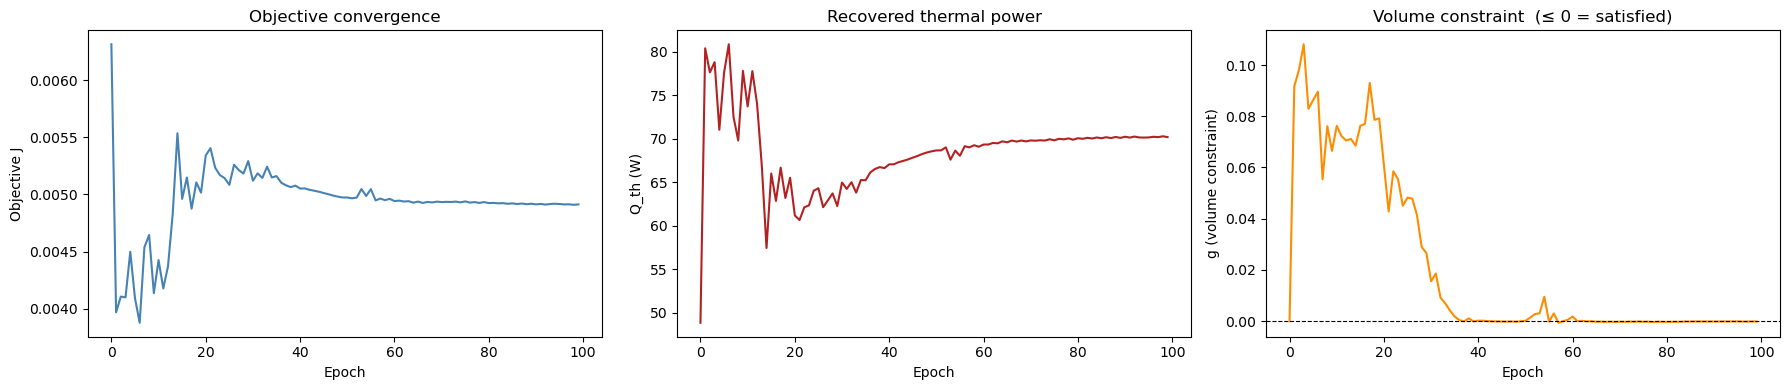

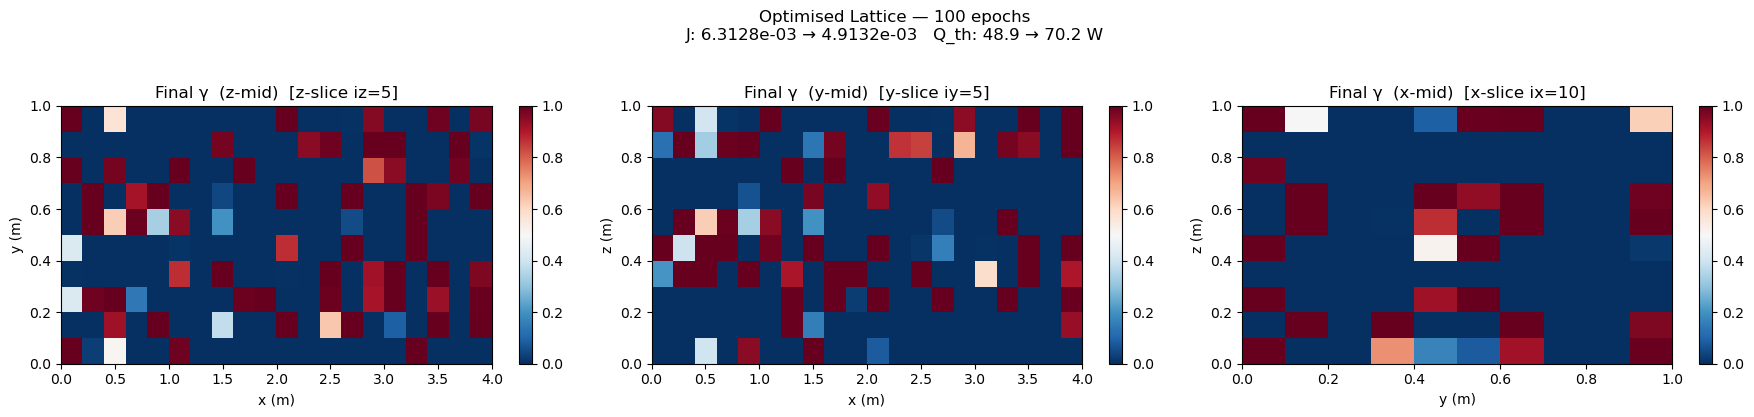

Control-point displacements:
  max  |d| = 0.3388 m
  mean |d| = 0.2304 m
Final solid fraction: 0.318


In [17]:
# ── Convergence history ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history['obj'], color='steelblue')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Objective J')
axes[0].set_title('Objective convergence')

axes[1].plot(history['therm_pwr'], color='firebrick')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Q_th (W)')
axes[1].set_title('Recovered thermal power')

axes[2].plot(history['vol_cons'], color='darkorange')
axes[2].axhline(0, color='k', linestyle='--', linewidth=0.8)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('g (volume constraint)')
axes[2].set_title('Volume constraint  (≤ 0 = satisfied)')

plt.tight_layout()
plt.show()

# ── Final design: three orthogonal slices ─────────────────────────────────
final_dv    = mma_state.x.ravel()
final_gamma = np.array(lattice_mat_frac(jnp.array(final_dv)))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
kw_g = dict(cmap='RdBu_r', vmin=0, vmax=1)
plot_slice(thermal_mesh, final_gamma, 'Final γ  (z-mid)', axis='z', ax=axes[0], **kw_g)
plot_slice(thermal_mesh, final_gamma, 'Final γ  (y-mid)', axis='y', ax=axes[1], **kw_g)
plot_slice(thermal_mesh, final_gamma, 'Final γ  (x-mid)', axis='x', ax=axes[2], **kw_g)
plt.suptitle(
    f'Optimised Lattice — {mma_state.epoch} epochs\n'
    f'J: {history["obj"][0]:.4e} → {history["obj"][-1]:.4e}   '
    f'Q_th: {history["therm_pwr"][0]:.1f} → {history["therm_pwr"][-1]:.1f} W',
    y=1.03,
)
plt.tight_layout()
plt.show()

# ── Final control-point displacements ─────────────────────────────────────
final_ctrl_np = np.array(final_dv).reshape(n_ctrl, 3)
disp_mags_f   = np.linalg.norm(final_ctrl_np, axis=1)
print(f'Control-point displacements:')
print(f'  max  |d| = {disp_mags_f.max():.4f} m')
print(f'  mean |d| = {disp_mags_f.mean():.4f} m')
print(f'Final solid fraction: {final_gamma.mean():.3f}')
